In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from ROOT import TH1F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json

#enable interactive plots
#%jsroot on  

#root.gStyle.SetOptStat(1111)
#root.gStyle.SetOptFit(1111) 
root.gStyle.SetOptStat(0)
root.gStyle.SetOptFit(0) 

Welcome to JupyROOT 6.30/04


In [2]:
#root.gStyle.SetOptStat(0)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.1f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/


V_current_level = 0.,0.,210.,210.,0.,210.,210.,210.,210.,210.,210.,210.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,210. #Leakage current measured at this V
V_current_monitor = V_current_level #Voltage up to which the current level is monitored
VBD_expected = 0.,0.,218.,218.,0.,218.,218.,218.,218.,218.,218.,218.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,218.
VBD_expected_sigma = 5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,5.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,5.
V_min_kfactor = 100.  #k-factor not used to calculate VBD if VBD<V_min_kfactor
I_thr = 1000  #4   #sensor discarded if I > I_thr [nA] in the voltage operation range [ 0-V_current_monitor ]
I_compliance = 1000 # VBD calculation begins when I < I_compliance  [nA]
I_compliance_minimum = 50 # [nA] VBD calculation performed only if compliance was set above this threshold
k_thr = 20. # 20  k value to define VBD using k-factor method
current_conversion_value = 1E9 # conversion from [A] (raw data) to [nA] (used in the final plots)
start_bd_calculation = 2 #BD calculation start from this sampled bias point: avoid considering the very first voltages of the bias sweep 
low_iv_range = 0.1  #0.1 #low and high ranges for I@100V plot [uA]
high_iv_range = 10 #10
low_vbd_range = 190 #190 #low and high ranges for VBD plot [V]
high_vbd_range = 230 #230
n_wafer = 28 #
n_pad = 256 # PAD
n_sensor = 24 # SENSOR
start_wafer = 1 #first wafer number in the dataset
start_pad = 1 #the first row of the wafer to be measured
start_sensor = 0 #the first column of the wafer to be measured 
bcurrent = False
bvoltage = True
bcategory = False
bnoisy = False
save = True
verbose = True
write_xl_for_db = False  #produces an xls file with the right format to be uploaded in the ETL database.
prefix_serial = "FBK_LF1_ROL_"
sensor = "Prototype LGAD"
sensor_geom = "16x16-T9"
vendor = "FBK"
production = "UFSD-LF"

dtz = datetime(2024, 6, 20, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

if(bcategory): 
    root.gStyle.SetPalette(3,palette) # custom palette used for Categories

if(bvoltage):
    #root.gStyle.SetPalette("Black Body") # palette for VBD
    root.gStyle.SetPalette(70) # palette for VBD

if(bcurrent or bnoisy):
    #root.gStyle.SetPalette("Black Body") # palette for I@V_current_level
    root.gStyle.SetPalette(70)
    root.TColor.InvertPalette()

invert_polarity=True

file_qa = root.TFile.Open("../../root_files/HPK5_16x16_IVtree.root")
tree_qa = file_qa.Get("Tree")
  
  
if(write_xl_for_db):
    xl_filename="UFSDLF_16x16_vendor_tests_ETLdb"
    wb = Workbook()
    ws = wb.active
    ws["A1"] = "SerialNumber"
    ws["B1"] = "ComponentType" 
    ws["C1"] = "Vendor" 
    ws["D1"] = "Production" 
    ws["E1"] = "Wafer" 
    ws["F1"] = "Geometry"
    ws["G1"] = "Row" 
    ws["H1"] = "Column"
    #ws["I1"] = "Vendor Leakage Current [uA]"
    #ws["J1"] = "Vendor Breakdown Voltage [V]" 
    #ws["K1"] = "Vendor Category"
    #ws["L1"] = "Gain Category"
    #ws["M1"] = "Comments"
    print("Xls File for database has been created")
  
  
counter_qa = 0
I_qa_100V = 0.
VBD_qa_u = 0.
VBD_qa_d = 0.
k_qa_u = []
k_qa_d = []
k_qa_u.append(0.)
k_qa_u.append(0.)
k_qa_d.append(0.)
k_qa_d.append(0.)

tests_json = []

current_levels_counter=[0,0,0,0,0,0]
vcount_vbd_qa = [[[0 for i in range(n_pad)] for j in range(n_sensor)] for k in range(n_wafer)]
vcount_i_qa = [[[0 for i in range(n_pad)] for j in range(n_sensor)] for k in range(n_wafer)]
vcount_bump_qa = [[[0 for i in range(n_pad)] for j in range(n_sensor)] for k in range(n_wafer)]
vvbd_qa = [[[0 for i in range(n_pad)] for j in range(n_sensor)] for k in range(n_wafer)]
vi_qa = [[[0 for i in range(n_pad)] for j in range(n_sensor)] for k in range(n_wafer)]
vbump_qa = [[[0 for i in range(n_pad)] for j in range(n_sensor)] for k in range(n_wafer)]
vi_raw = [[[[] for i in range(n_pad)] for j in range(n_sensor)] for k in range(n_wafer)]
v_raw = [[[[] for i in range(n_pad)] for j in range(n_sensor)] for k in range(n_wafer)]
#vnoisy_qa = None
hI_qa_100V = []
hV_qa = []
hbump_qa = []
hnoisy_qa = []
hcount_qa = []
min_I = []

'''
for i in range(n_wafer):
    hI_qa_100V.append( TH2F( "I_qa_"+str(V_current_level[i])+"V_W"+str(i+1), "I@"+str(V_current_level[i])+"V on-wafer W"+str(i+1), n_sensor,start_sensor,(start_sensor+n_sensor),n_pad,start_pad,(start_pad+n_pad) ) )
    hV_qa.append( TH2F( "V_qa_W"+str(i+1), "VBD on-wafer W"+str(i+1), n_sensor,start_sensor,(start_sensor+n_sensor),n_pad,start_pad,(start_pad+n_pad) ) )
    #hV_qa.append( TH1F( "V_qa_W"+str(i+1), "VBD on-wafer W"+str(i+1), int((450-0)/10.), 0, 450 ) )
    min_I.append(1000)

    hbump_qa.append( TH2F( "bump_qa_W"+str(i+1), "Categories on-wafer W"+str(i+1), n_sensor,start_sensor,(start_sensor+n_sensor),n_pad,start_pad,(start_pad+n_pad)) )
    hnoisy_qa.append( TH2F( "noisy_qa_W"+str(i+1), "Bad pads on-wafer W"+str(i+1), n_sensor,start_sensor,(start_sensor+n_sensor),n_pad,start_pad,(start_pad+n_pad)) )
'''

dumb_counter= 0. # Total number of sensors/measurements in the root file
non_empty_counter= 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter= 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
total_sensors_counter_qa= 0. #Fraction of sensors whose category can be properly defined
good_sensors_counter_qa= 0. #Fraction of GOOD sensors
bad_sensors_counter_qa= 0. #Fraction of BAD sensors
medium_sensors_counter_qa= 0. #Fraction of MEDIUM sensors
iv_quality = bool() # Boolean reflecting the quality of the IV curve: sensor is BAD whenever iv_quality is set to False

save_path = '/Users/icosivi/Desktop/plot_HPK5/'

In [3]:
for event in tree_qa:
    dumb_counter+=1
    if(int(event.IPAD.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.IPAD.at(event.IPAD.size()-1)<0 ): 
        Iback = [float(-i) for i in event.IPAD]
        for idx, i in enumerate(event.IPAD):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.pad)+" column "+str(event.sensor)+" with negative current detected. Changing polarity.")
      else:
        Iback = [i for i in event.IPAD]
        for idx, i in enumerate(event.IPAD):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.IPAD.size()-1):
           v_raw[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.pad)+" column "+str(event.sensor)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.IPAD.size()-1): 
           v_raw[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        VBD_qa_u = -1000.
        VBD_qa_d = -1000.
        
        type_counter = 0
        type_counter_I_qa = 0
        type_counter_V_qa_u = 0
        type_counter_V_qa_d = 0
      
      
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
            if( Vbias[i]==V_current_level[event.wafer-start_wafer] ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*(V_current_level[event.wafer-start_wafer]-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=V_current_monitor[event.wafer-start_wafer] and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break

        I_qa_100V = current_conversion_value*I_qa_100V
        if( I_qa_100V<0. ): 
          iv_quality=False
          
        ### VBD calculation ###
        if( Iback[ -1 ]>I_compliance_minimum*(1./current_conversion_value) ):
          ### VBD "up" (Calculation start from the end of the Voltage array downwards) ###
          for i in reversed(range(start_bd_calculation,int(len(Iback))-1)):
            if(Vbias[len(Iback)-1]<V_min_kfactor): 
                VBD_qa_u = Vbias[len(Iback)-1]
                break 
            
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):
              k_qa_u[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_u[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i]) 
              if( k_qa_u[0]<k_thr and k_qa_u[1]>=k_thr ):
                VBD_qa_u = Vbias[i] 
                break 
              
         
          ### VBD "down" (Calculation start from the beginning of the Voltage array upwards) ###
          for i in range(start_bd_calculation,int(len(Iback))-1):
            if(Vbias[len(Iback)-1]<V_min_kfactor):
                VBD_qa_d = Vbias[len(Iback)-1] 
                break 
      
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):    
              k_qa_d[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_d[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i])
              if( k_qa_d[0]<k_thr and k_qa_d[1]>=k_thr ):
                VBD_qa_d = Vbias[i] 
                break
        
        #if event.wafer==7 and event.sensor==19 and VBD_qa_u>225:
          #print(str(VBD_qa_u)+"     "+str(VBD_qa_d))
      
        if(VBD_qa_u!=-1000 and VBD_qa_d!=-1000): 
          vvbd_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += VBD_qa_u
          vcount_vbd_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += 1
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += 1
      
        #if( VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_d!=-1000 and VBD_qa_d<=(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) ):
          #if(verbose): 
            #print("!!! SENSOR WITH CURRENT JUMPS ALERT  !!!: from wafer "+str(event.wafer)+" pad "+str(event.pad)+" sensor "+str(event.sensor))
        
        if( iv_quality and VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_u<(VBD_expected[event.wafer-start_wafer]+3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_d!=-1000 ):
          if( VBD_qa_d>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) ):
           vbump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += 1 
           vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += 1 
          else:
           vbump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += 2
           vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += 1
        elif( np.logical_not(iv_quality) or (VBD_qa_d!=-1000 and VBD_qa_u!=-1000 and (VBD_qa_u<=(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) or VBD_qa_u>=(VBD_expected[event.wafer-start_wafer]+3*VBD_expected_sigma[event.wafer-start_wafer]))) ):
          vbump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += 100
          vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += 1
        else: 
          vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" pad "+str(event.pad)+" sensor "+str(event.sensor)+" has Current within acceptance, but VBD could not be calculated. PLEASE CHECK.")
      else:
        vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += -1000
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" pad "+str(event.pad)+" sensor "+str(event.sensor)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      vcount_bump_qa[event.wafer-start_wafer][event.sensor-start_sensor][event.pad-start_pad] += -1000
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" pad "+str(event.pad)+" sensor "+str(event.sensor)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [ ]:
value_to_count = 100  # The value you want to count

# Create a boolean mask where True indicates the value matches
mask = np.array(vbump_qa) == value_to_count

# Sum the True values in the mask to get the count
count = np.sum(mask)

print(f"The number of entries with value {value_to_count} is: {count}")
print(str(len(np.array(vbump_qa))))

In [ ]:
value_to_count = 100  # The value you want to count

# Create a boolean mask where True indicates the value matches
mask = np.array(vbump_qa[2]) == value_to_count

# Sum the True values in the mask to get the count
count = np.sum(mask)

print(f"The number of entries with value {value_to_count} is: {count}")
print(str(len(np.array(vbump_qa[2]))))

In [ ]:
mean_array_v = []
mean_array_i = []
sigma_array_v = []
sigma_array_i = []
for i in range(n_wafer):
  if i==2 or i==3 or i==5 or i==6 or i==7 or i==8 or i==9 or i==10 or i==11 or i==27:
    hI_qa_100V.append( TH1F( "hI_total_pad_"+str(i+1), "Overview of I@210V in HPK5 "+str(i), 200, -1, 10) )
    hV_qa.append( TH1F( "hV_total_pad_"+str(i+1), "Overview of pad VBD in HPK5 "+str(i), 20, 150, 250 ) )

for i in range(n_wafer):
     #if i==2 | i==3 | i==5 | i==6 | i==7 | i==8 | i==9 | i==10 | i==11 | i==27:
      for j in range(n_sensor):
        for k in range(256):
             if(vcount_vbd_qa[i][j][k]!=0): 
               hV_qa[i].Fill( vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k] )
               
             if(vcount_i_qa[i][j][k]!=0): 
              hI_qa_100V[i].Fill( vi_qa[i][j][k]/vcount_i_qa[i][j][k] )             
 
for i in range(n_wafer):
  #print(i)
  if i==2 or i==3 or i==5 or i==6 or i==7 or i==8 or i==9 or i==10 or i==11 or i==27:
   gaus_func1 = root.TF1("gausx", "gaus", 0, 1)
   gaus_func2 = root.TF1("gausy", "gaus", 200, 240)
   hI_qa_100V[i].Fit(gaus_func1,'R')
   hV_qa[i].Fit(gaus_func2,'R')
   print("pippo")
   mean_array_i.append(gaus_func1.GetParameter(1))
   mean_array_v.append(gaus_func2.GetParameter(1))
   sigma_array_i.append(gaus_func1.GetParameter(2))
   sigma_array_v.append(gaus_func2.GetParameter(2))
 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_labels = [3, 4, 6, 7, 8, 9, 10, 11, 12, 28]
y_values = [83, 79, 87.5, 79, 96, 96, 96, 96, 87.5, 87.5]

plt.figure(figsize=(10, 6))

# Create a numerical x-axis for the bar positions
x_positions = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

plt.bar(x_positions, y_values)
#plt.plot(x_positions, y_values, marker='o',markersize=14) 

plt.xlabel("Wafer number",fontsize=18)
plt.ylabel("Sensor Yield",fontsize=18)

plt.xticks(x_positions, x_labels)  # Set the x-axis ticks and labels
plt.xlim(0, 11) # set the limit of the x axis to 0-9
plt.ylim(0, 105) # set the limit of the x axis to 0-9

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_labels = [3,4,6,7,8,9,10,11,12,28]

def create_boxplot(means, stds, x_labels):
  data = []
  for mean, std in zip(means, stds):
      data.append(np.random.normal(loc=mean, scale=std, size=100))  # Generate 100 samples

  # Create the box plot
  plt.figure(figsize=(12, 12))
  plt.boxplot(data, labels=x_labels)
  plt.xlabel('Wafer number',fontsize=18)
  plt.ylabel('I@210V [nA]',fontsize=18)
  plt.ylim(0,0.5)
  plt.title('Pad I@210V Box Plot HPK5',fontsize=22)
  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)
  plt.show()

create_boxplot(mean_array_i, sigma_array_i, x_labels)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_labels = [3,4,6,7,8,9,10,11,12,28]

def create_boxplot(means, stds, x_labels):
  data = []
  for mean, std in zip(means, stds):
      data.append(np.random.normal(loc=mean, scale=std, size=100))  # Generate 100 samples

  # Create the box plot
  plt.figure(figsize=(12, 12))
  plt.boxplot(data, labels=x_labels)
  plt.xlabel('Wafer number',fontsize=18)
  plt.ylabel('VBD [V]',fontsize=18)
  plt.ylim(205,230)
  plt.title('Pad VBD Box Plot HPK5',fontsize=22)
  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)
  plt.show()

create_boxplot(mean_array_v, sigma_array_v, x_labels)

In [ ]:
from ROOT import TCanvas

hI_total_pad = TH1F( "hI_total_pad", "Overview of I@210V in HPK5", 200, -1, 10)
hV_total_pad = TH1F( "hV_total_pad", "Overview of pad VBD in HPK5", 20, 150, 250 )

for i in range(n_wafer):
 for j in range(n_sensor):
        row_counter=0
        for k in range(256):
             if k%16==0 and k!=0:
              row_counter+=1
             roww = k+start_pad-row_counter*16
             coll = row_counter+start_pad
             
             if(vcount_vbd_qa[i][j][k]!=0): 
               hV_total_pad.Fill( vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k] )
               
             if(vcount_i_qa[i][j][k]!=0): 
               hI_total_pad.Fill( vi_qa[i][j][k]/vcount_i_qa[i][j][k] )
               
cx = TCanvas( "cx", "cx", 900,900)
cx.cd()
gaus_func1 = root.TF1("gausx", "gaus", 0, 1)
gaus_func2 = root.TF1("gausy", "gaus", 200, 240)
hI_total_pad.GetXaxis().SetTitle("I@210V [nA]")
hI_total_pad.Draw()
hI_total_pad.Fit(gaus_func1,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()

cy = TCanvas( "cy", "cy", 900,900)
cy.cd()
hV_total_pad.Draw("sames")
hV_total_pad.GetXaxis().SetTitle("VBD [V]")
hV_total_pad.Fit(gaus_func2,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()#

combined_VBD
.DS_Store
8.png
9.png
14.png
15.png
17.png
16.png
12.png
13.png
11.png
10.png
21.png
20.png
22.png
23.png
combined_cat_1000nA
combined_I
18.png
24.png
19.png
4.png
5.png
7.png
6.png
2.png
3.png
1.png
combined_VBD
.DS_Store
8.png
9.png
14.png
15.png
17.png
16.png
12.png
13.png
11.png
10.png
21.png
20.png
22.png
23.png
combined_cat_1000nA
combined_I
18.png
24.png
19.png
4.png
5.png
7.png
6.png
2.png
3.png
1.png
combined_VBD
.DS_Store
8.png
9.png
14.png
15.png
17.png
16.png
12.png
13.png
11.png
10.png
21.png
20.png
22.png
23.png
combined_cat_1000nA
combined_I
18.png
24.png
19.png
4.png
5.png
7.png
6.png
2.png
3.png
1.png
combined_VBD
.DS_Store
8.png
9.png
14.png
15.png
17.png
16.png
12.png
13.png
11.png
10.png
21.png
20.png
22.png
23.png
combined_cat_1000nA
combined_I
18.png
24.png
19.png
4.png
5.png
7.png
6.png
2.png
3.png
1.png
combined_VBD
.DS_Store
8.png
9.png
14.png
15.png
17.png
16.png
12.png
13.png
11.png
10.png
21.png
20.png
22.png
23.png
combined_cat_1000nA
combined_

Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/1.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/2.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/3.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/4.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/5.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/6.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/7.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/8.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/9.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/10.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/plot_HPK5/11.png has been creat

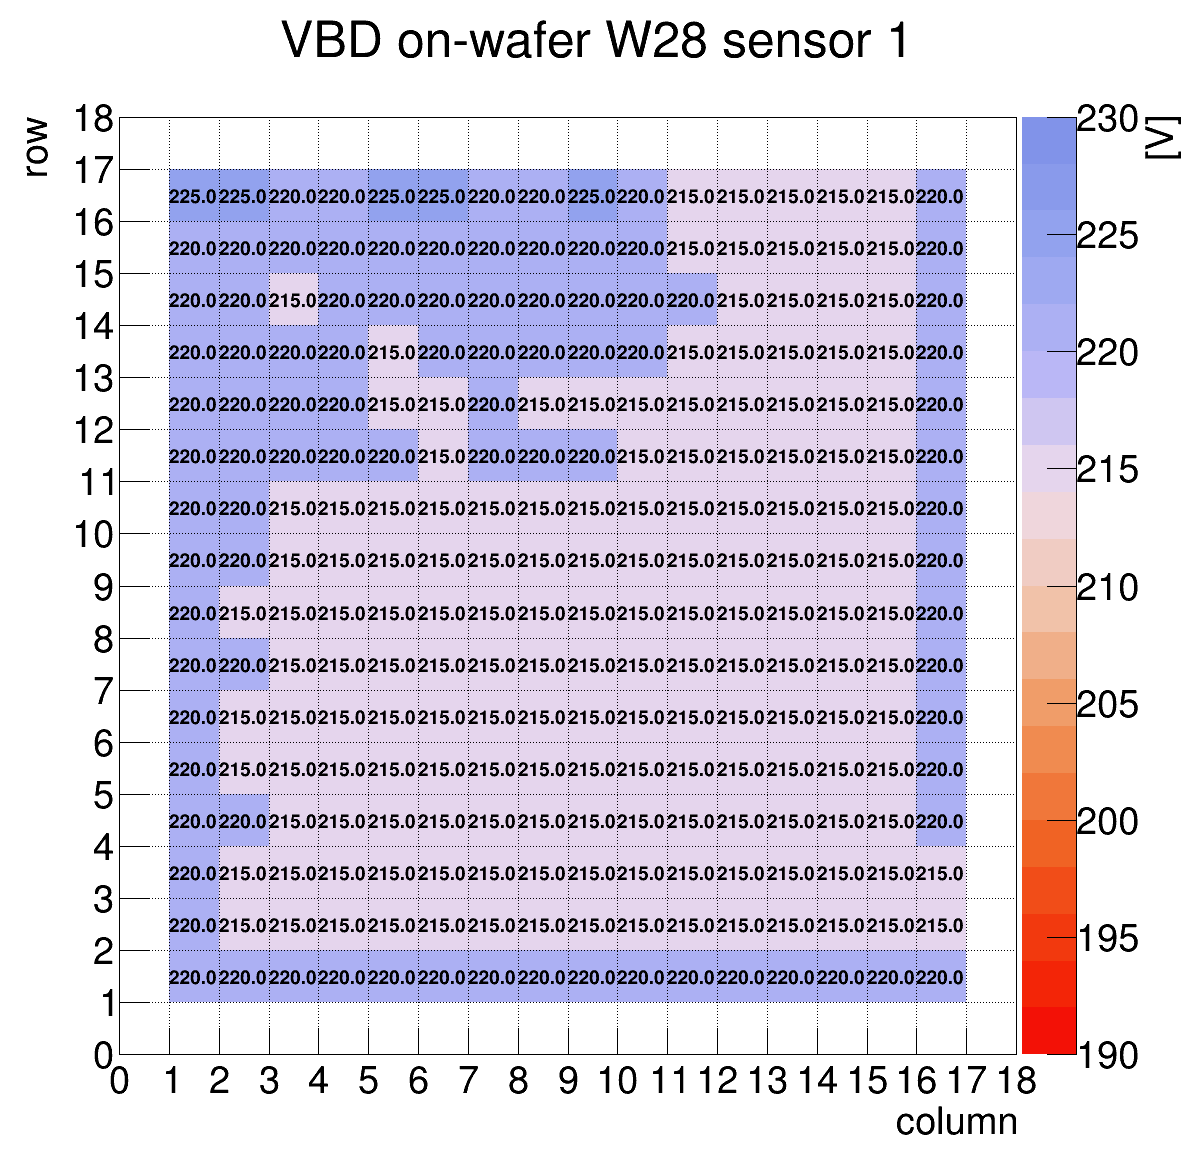

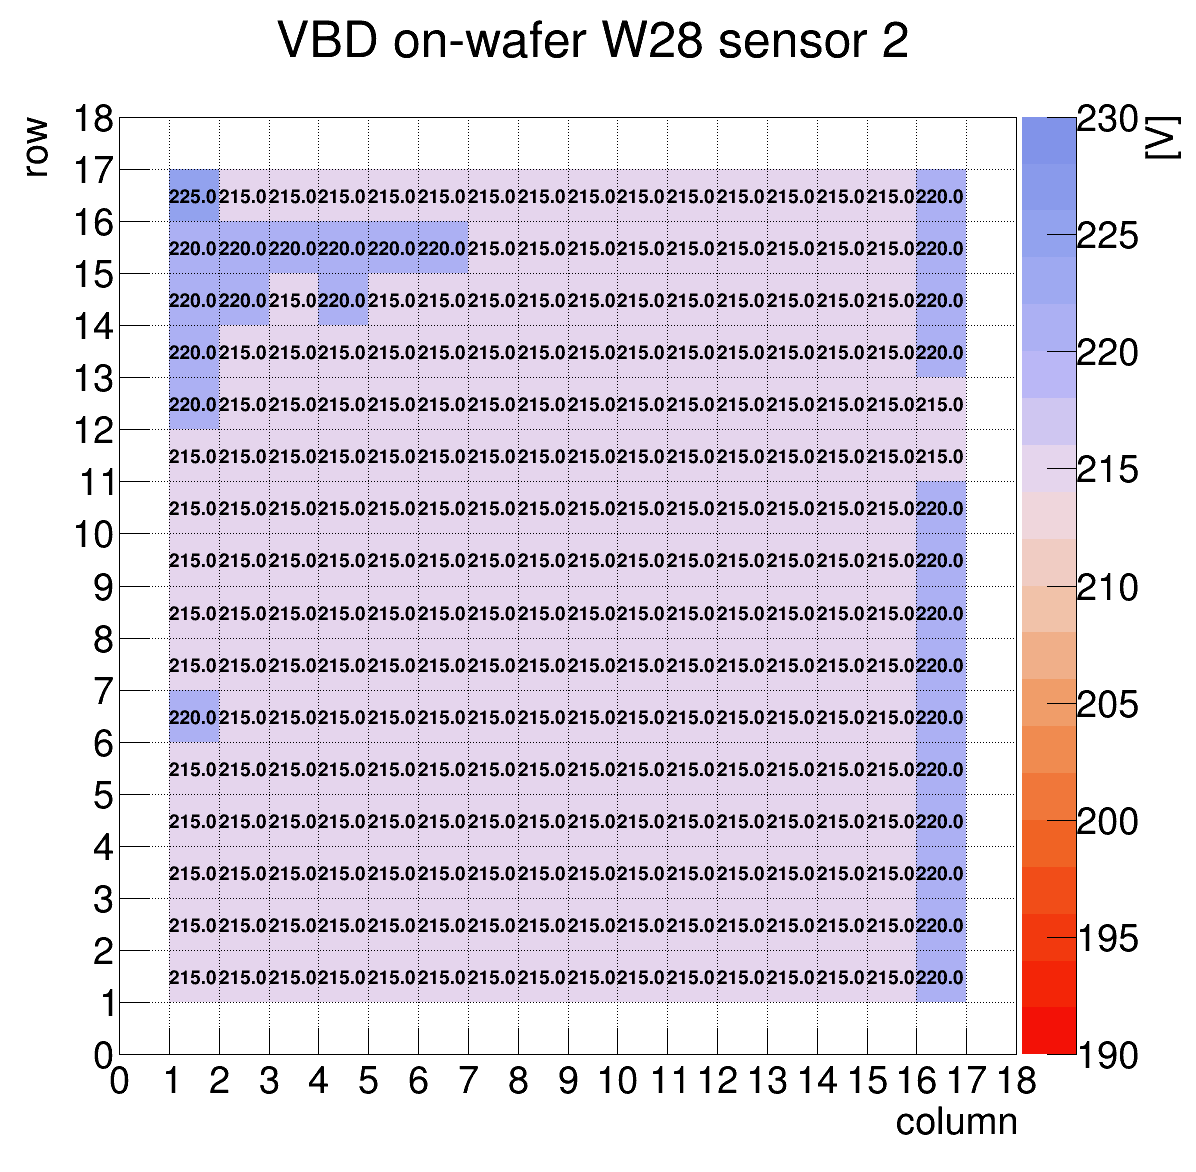

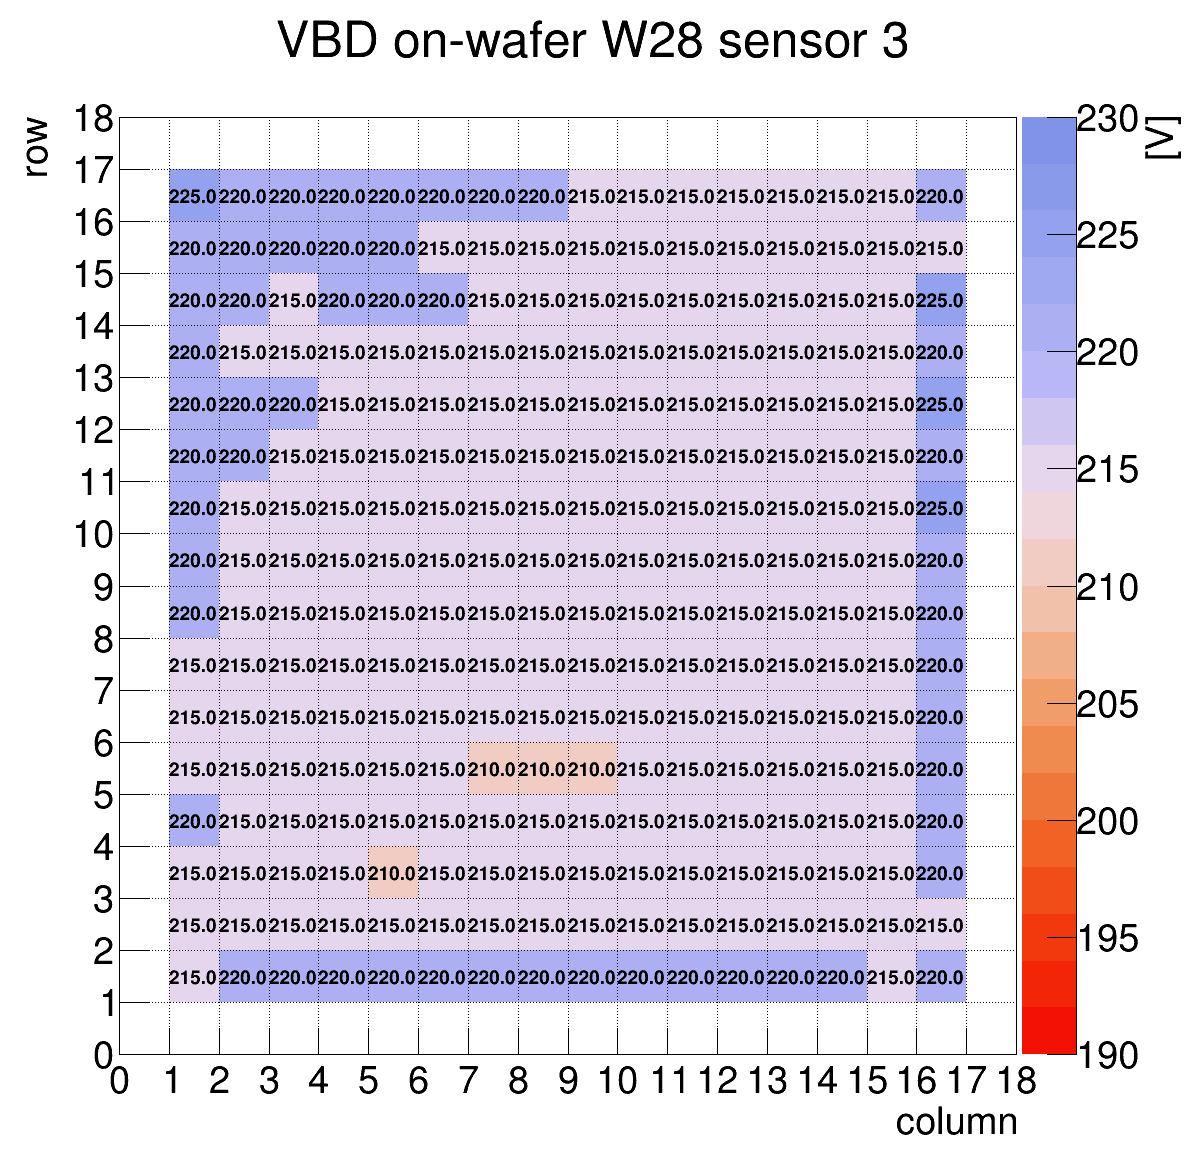

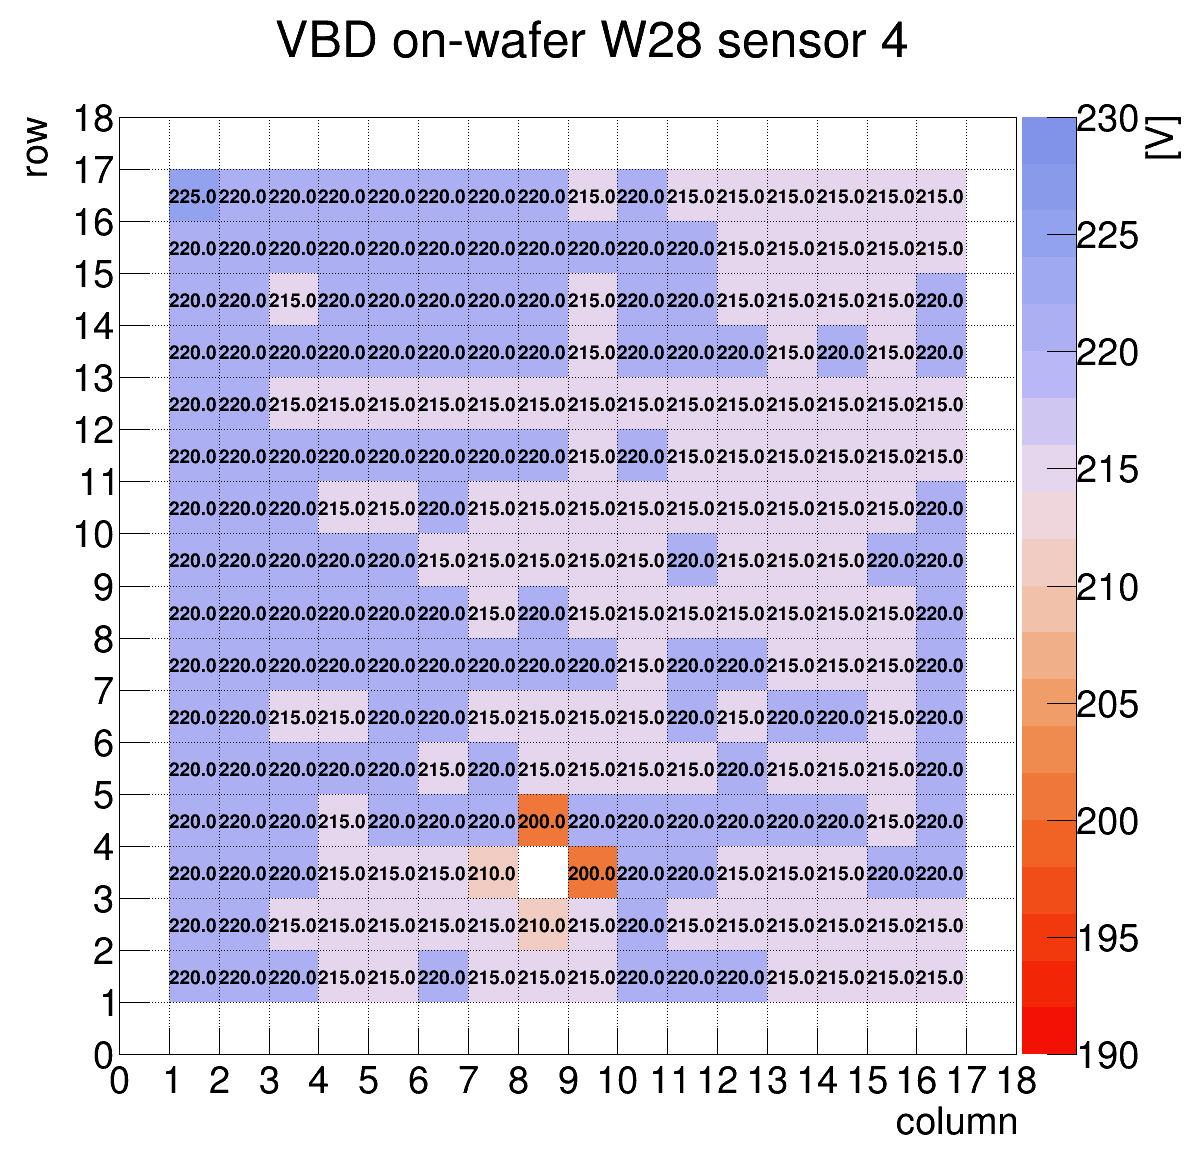

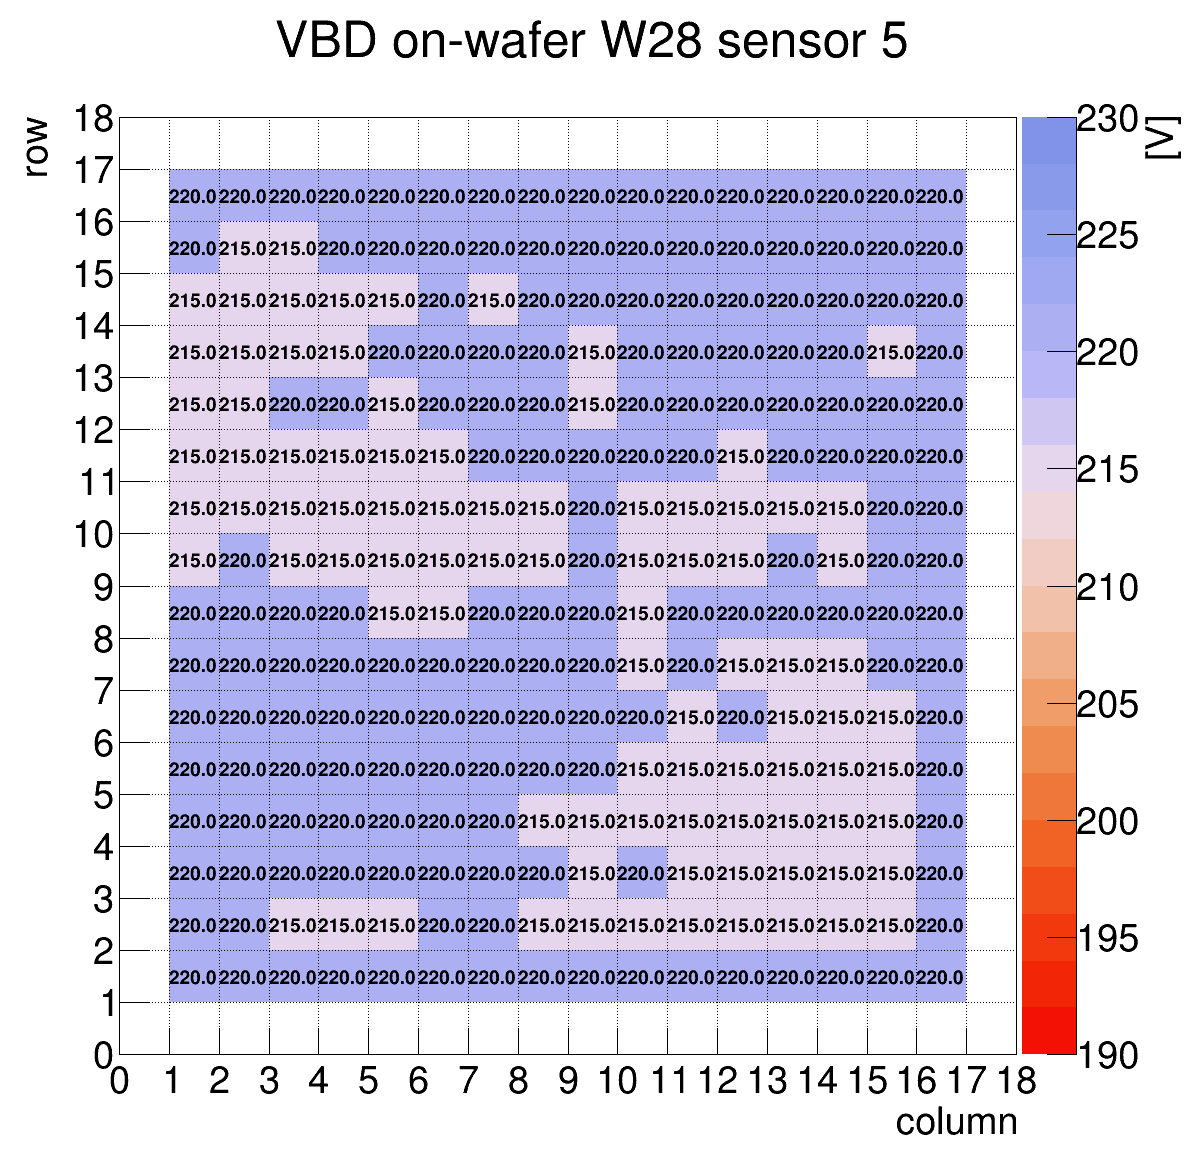

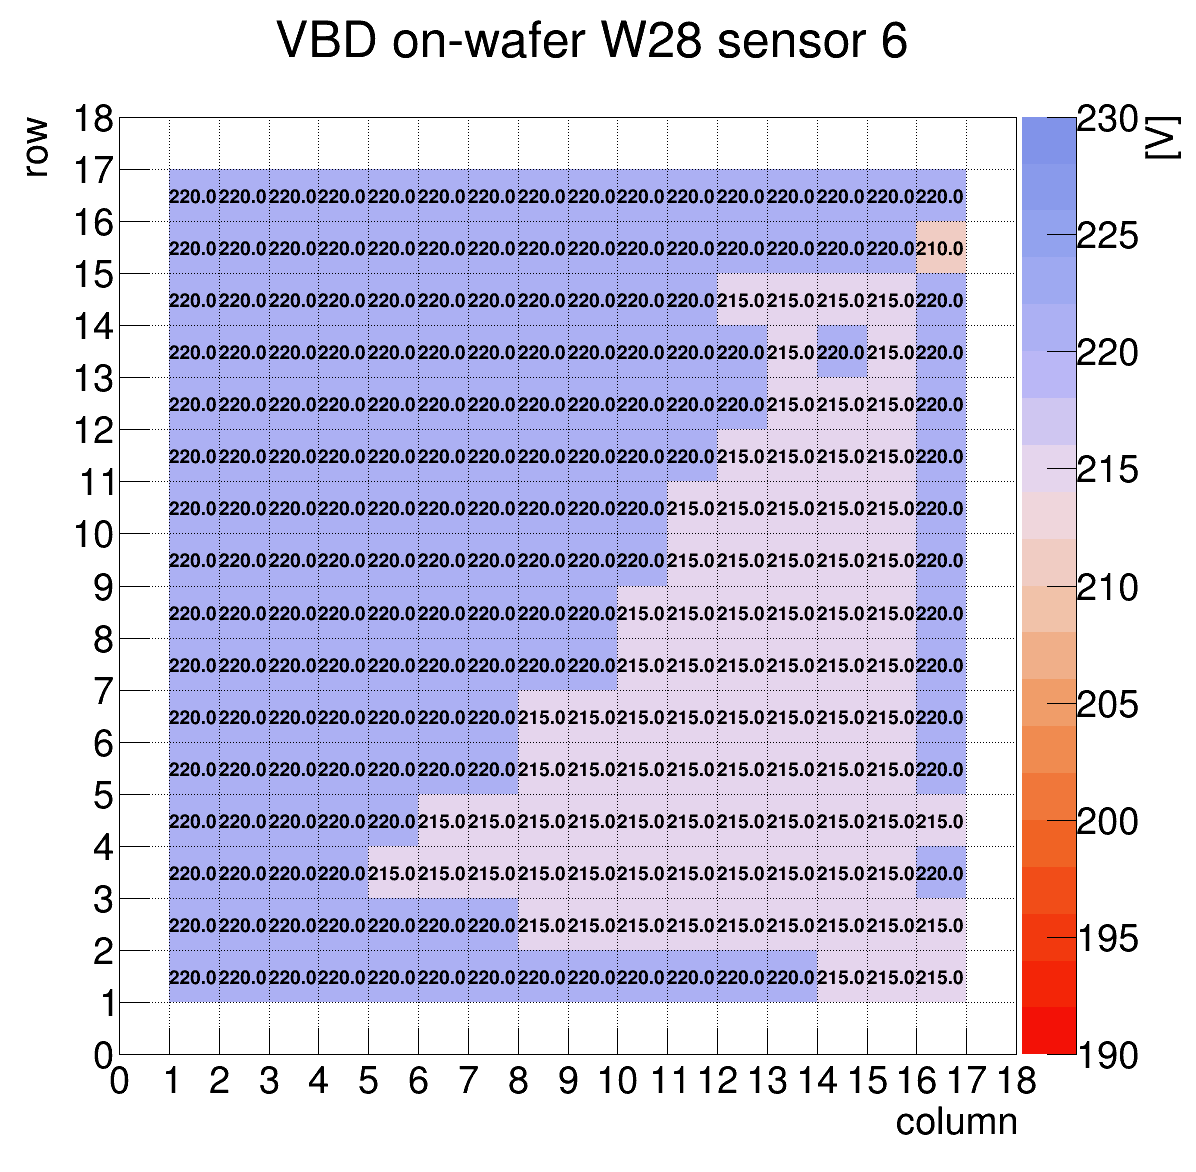

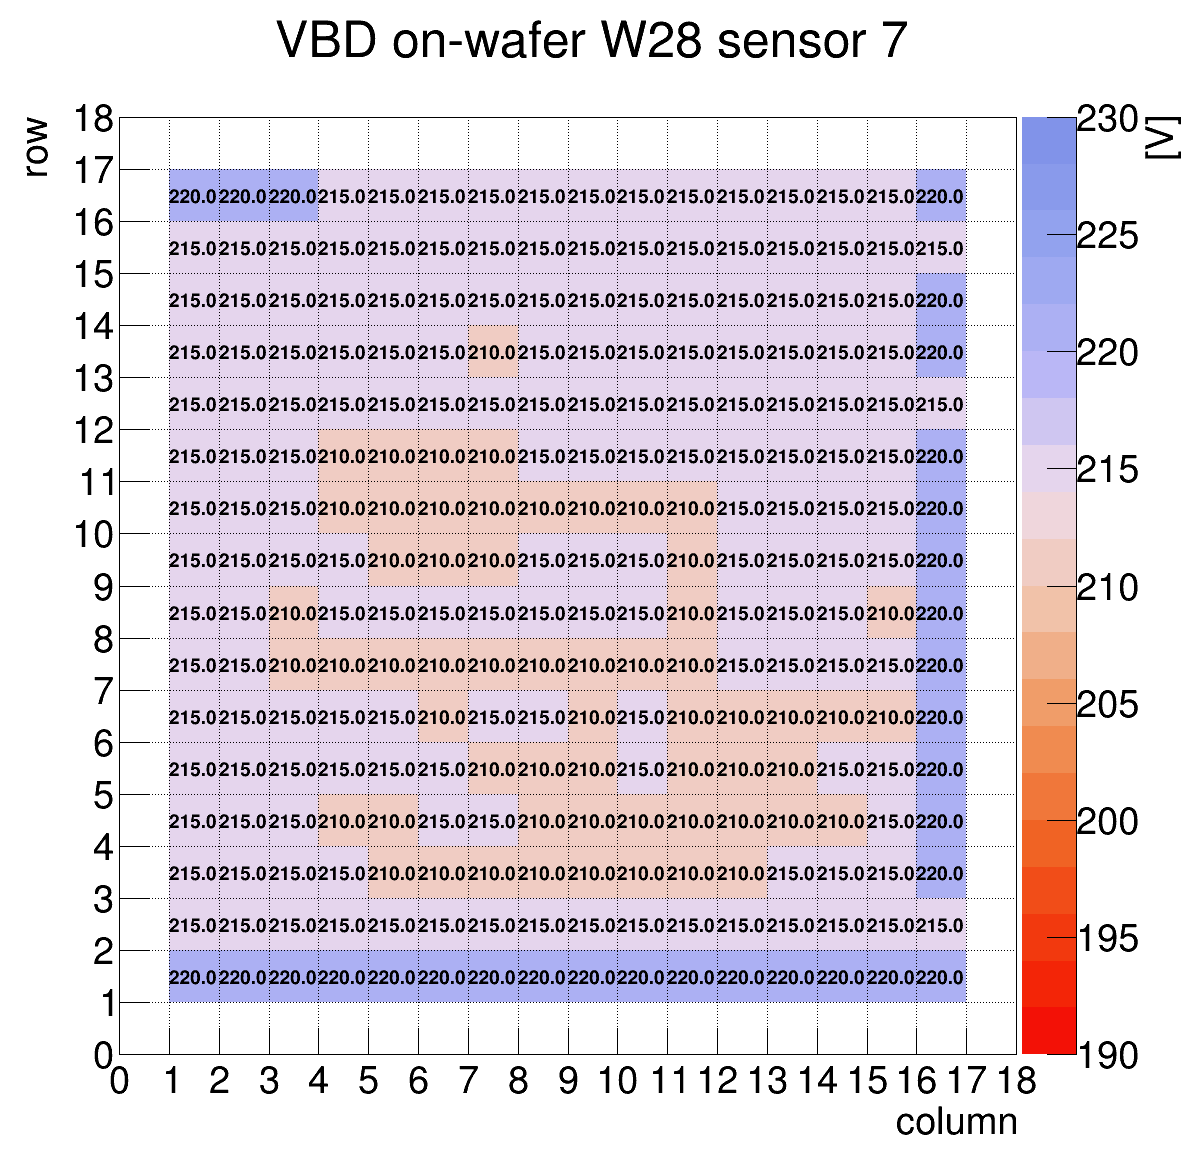

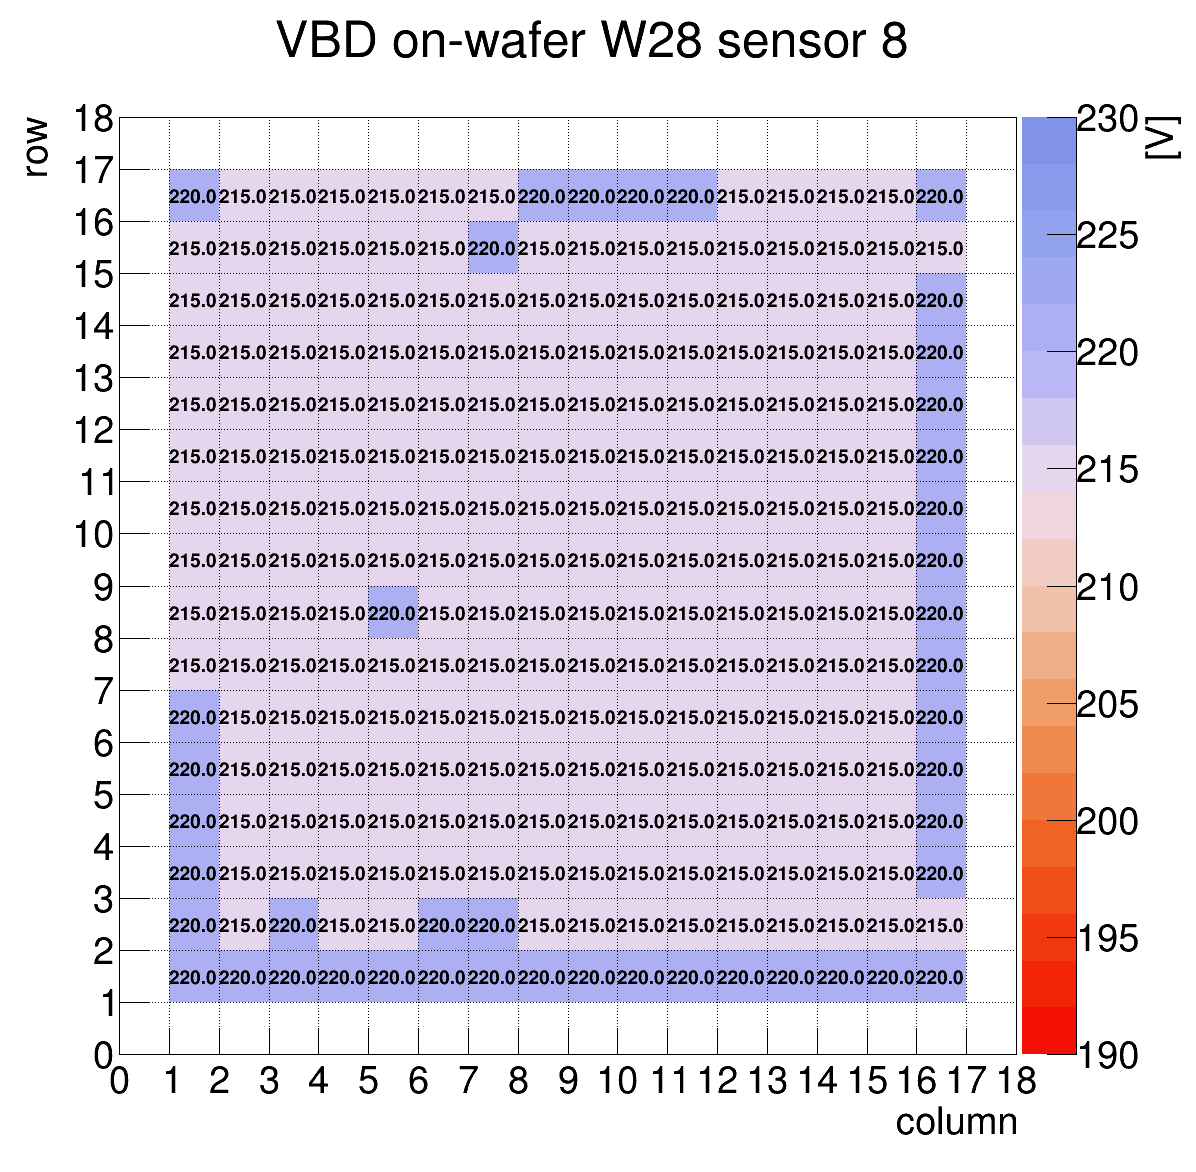

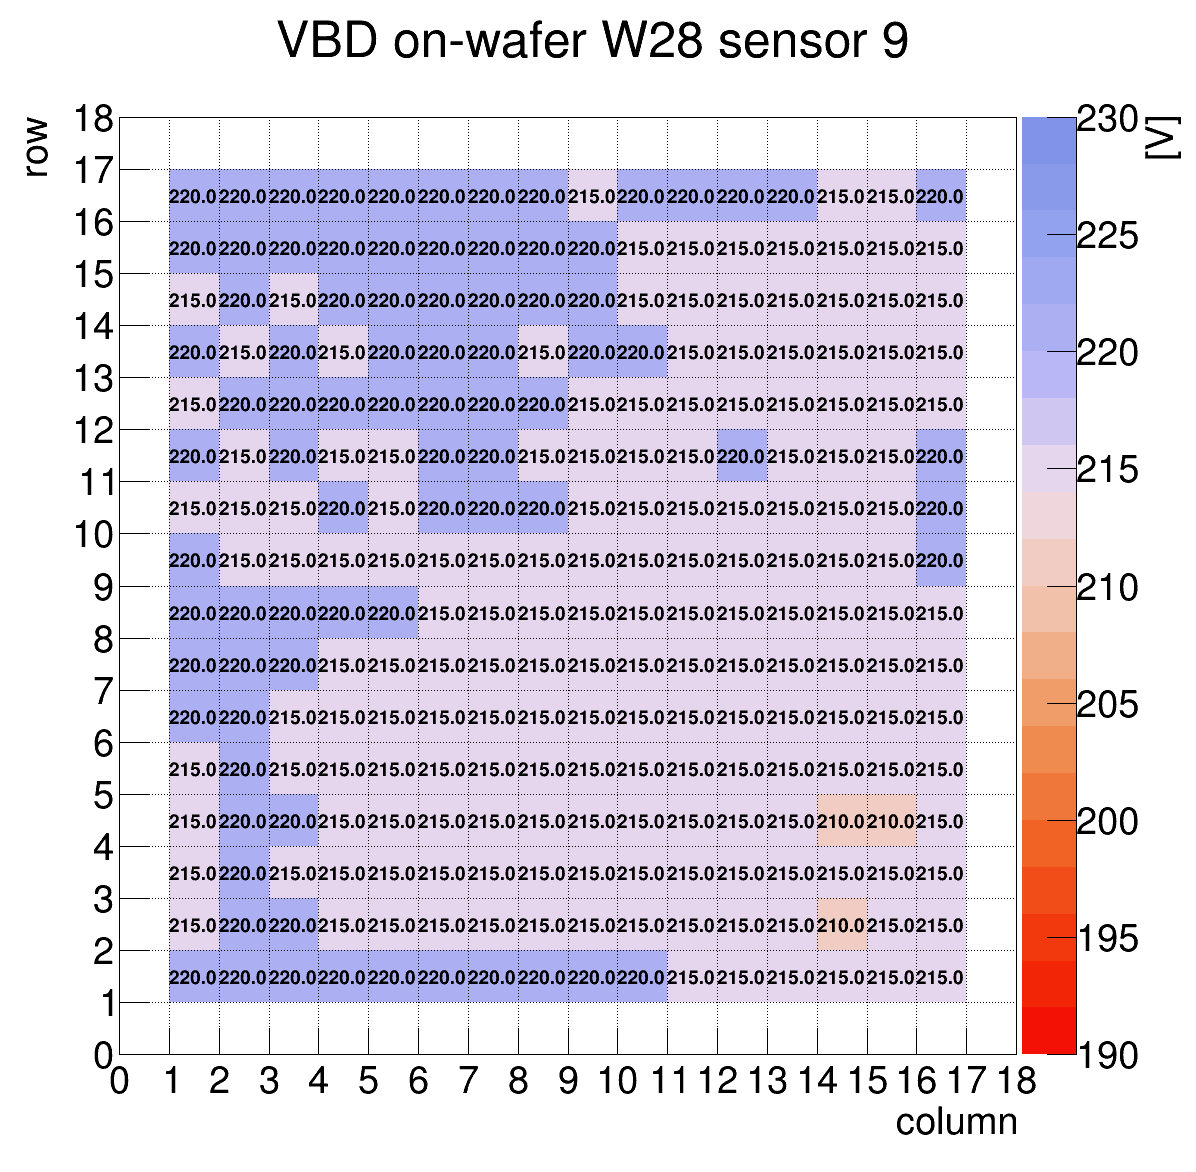

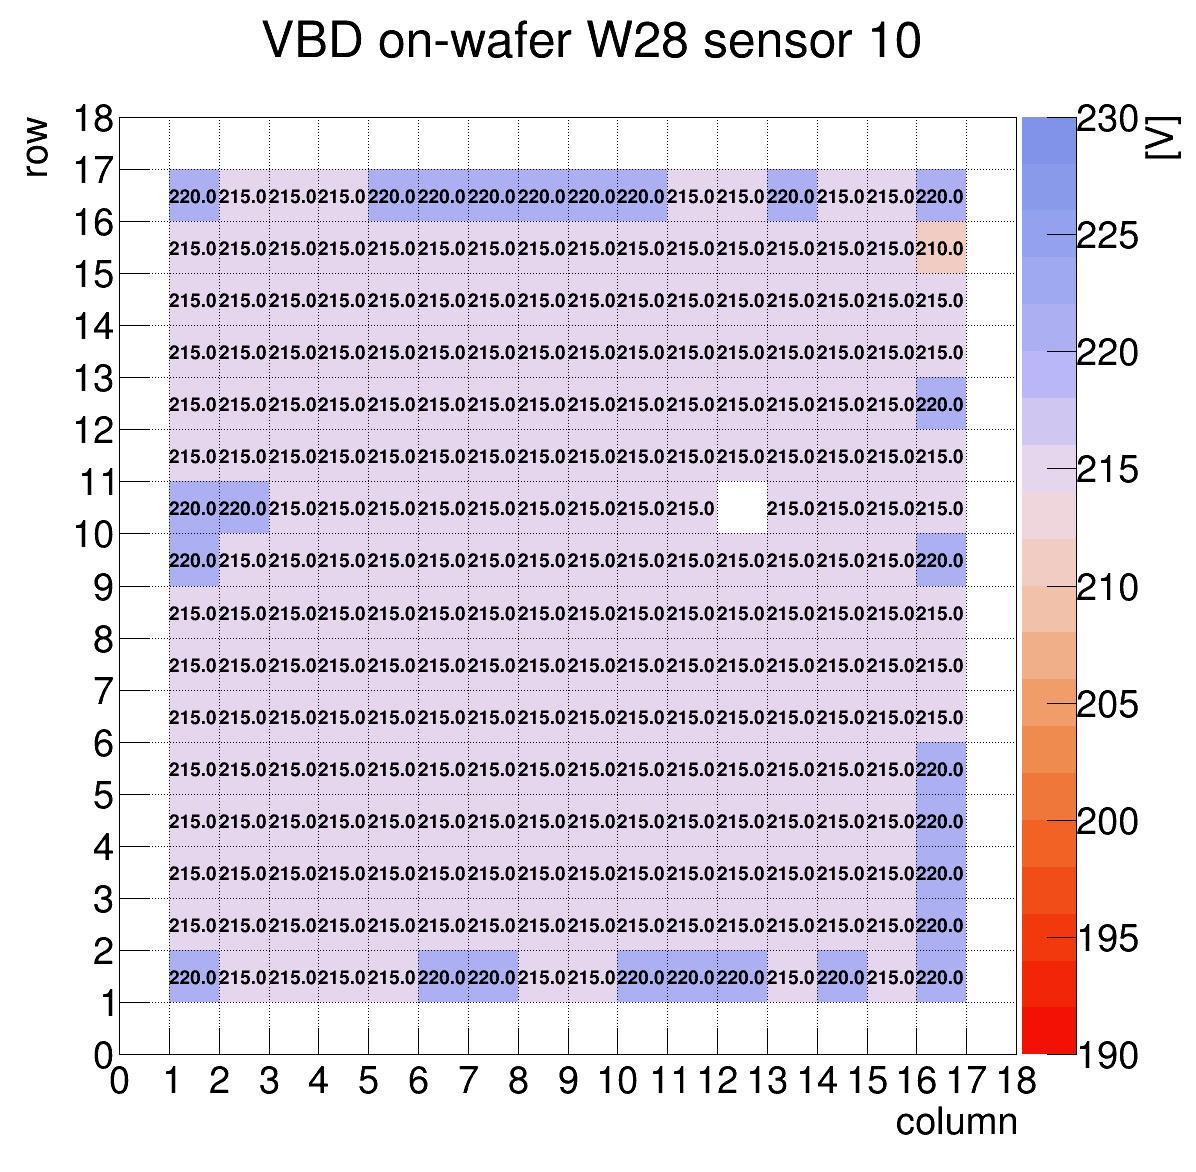

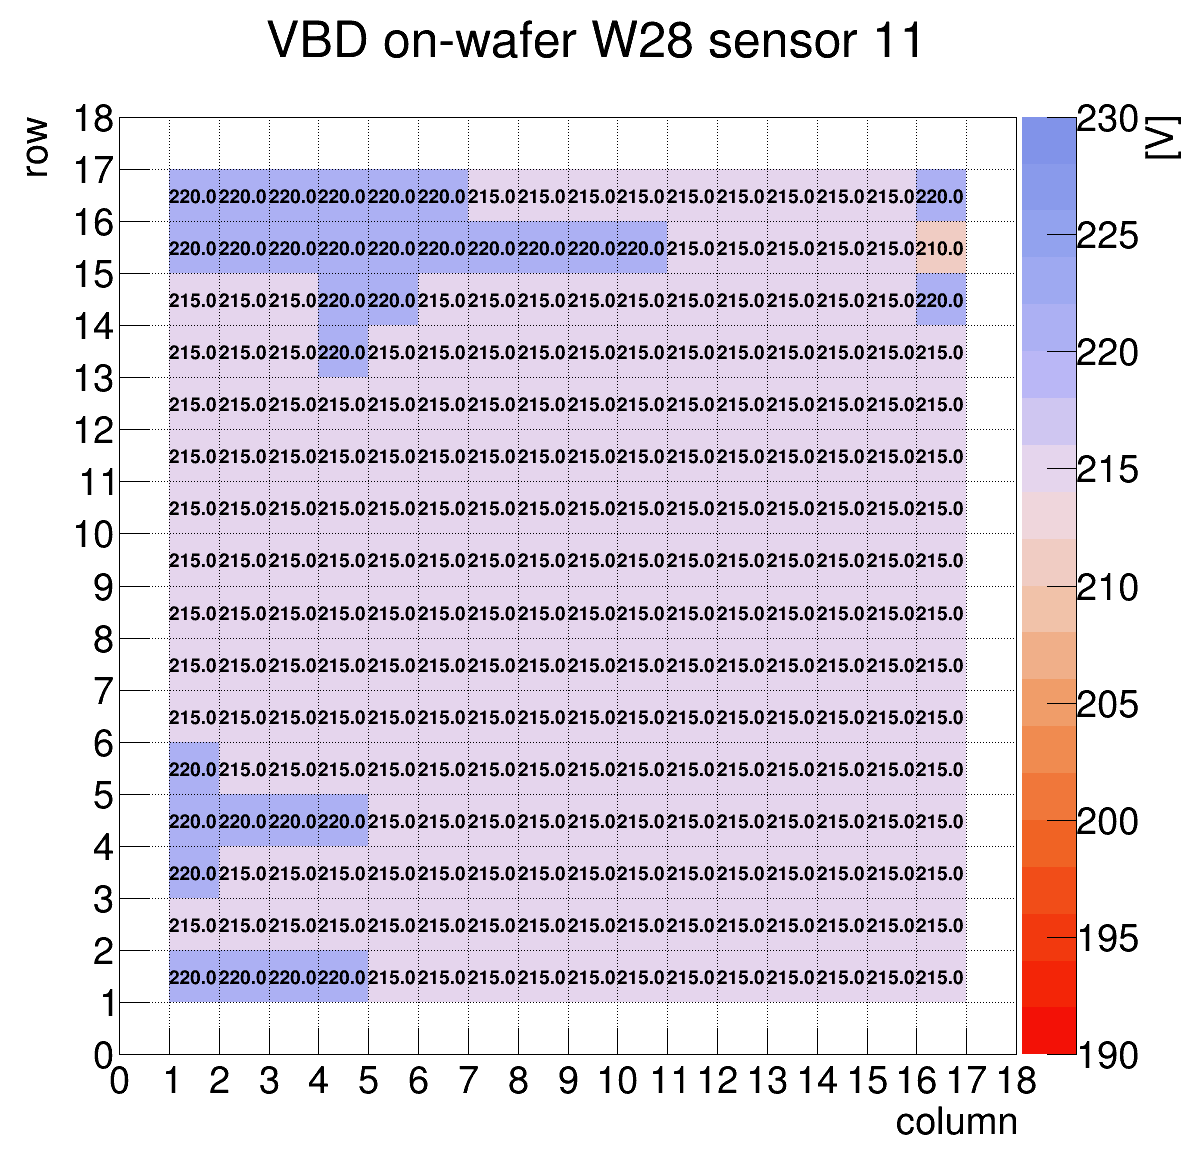

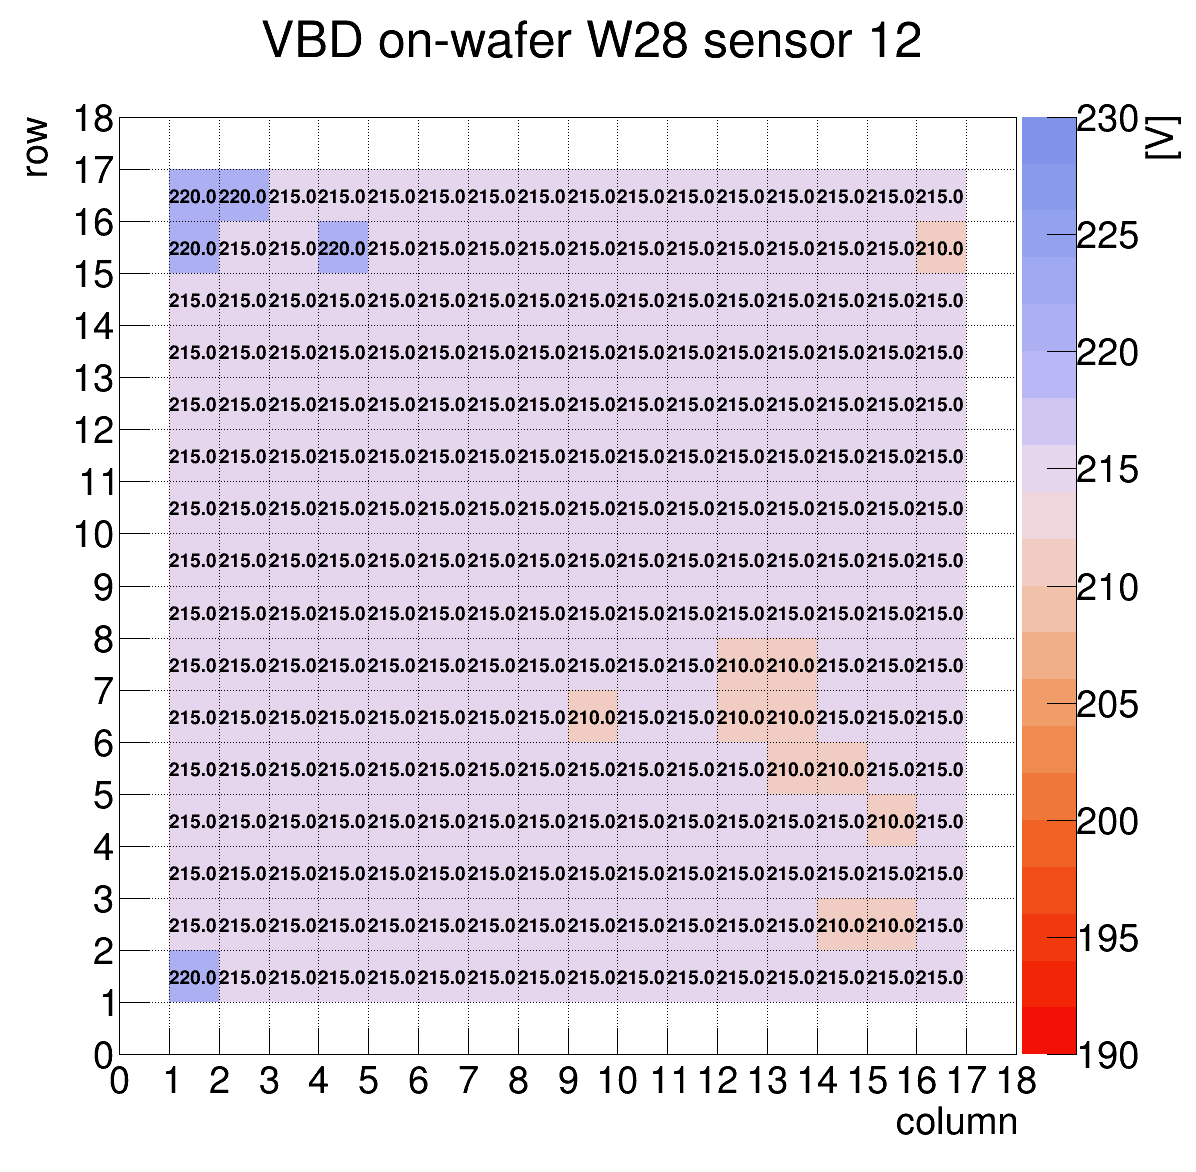

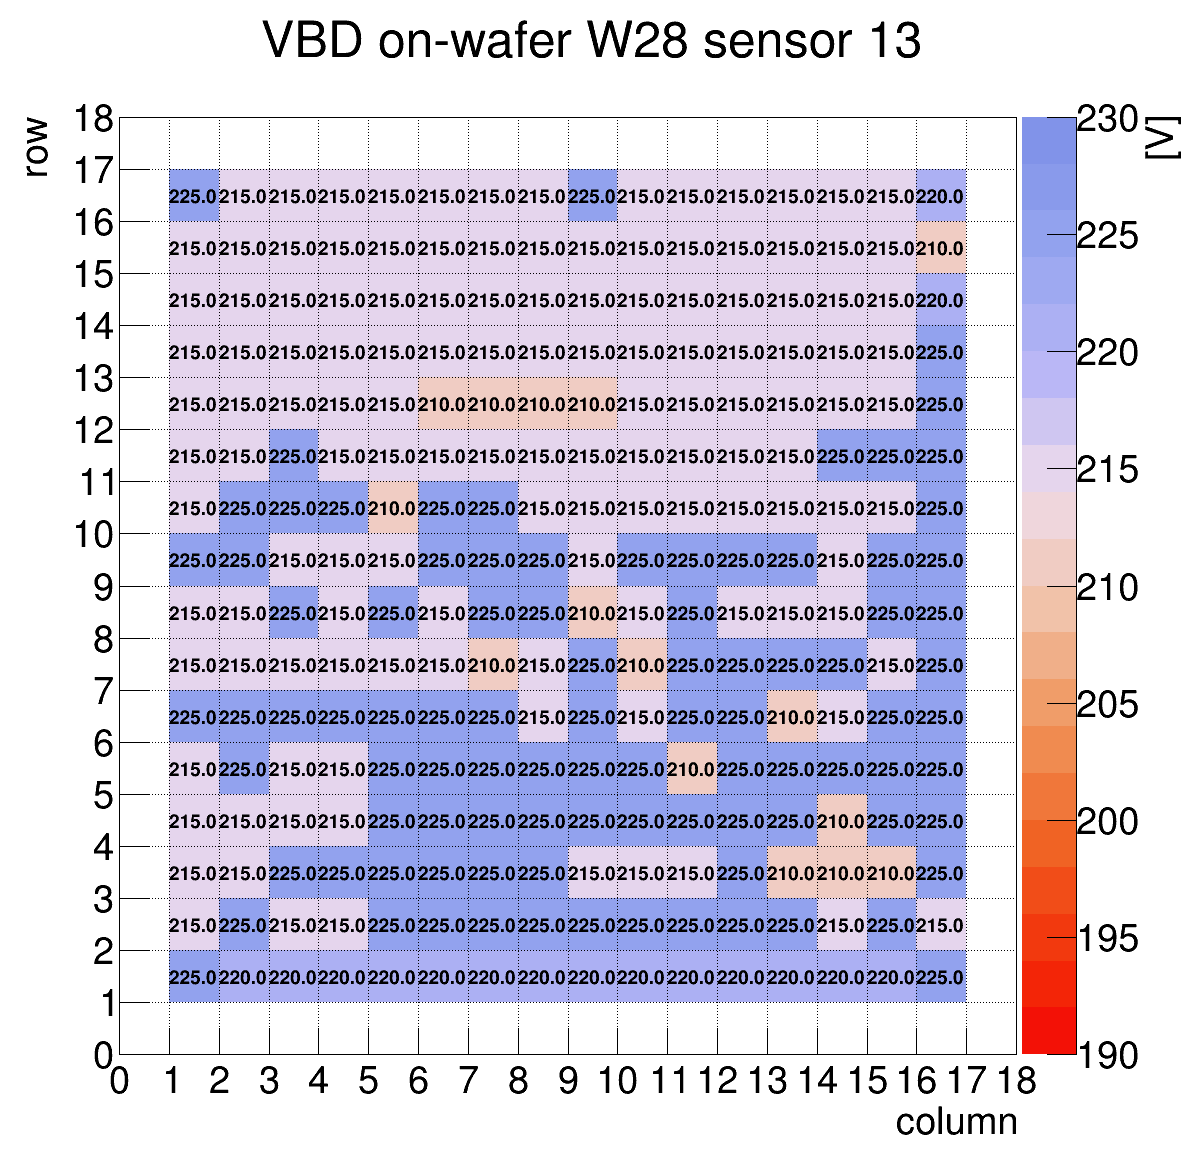

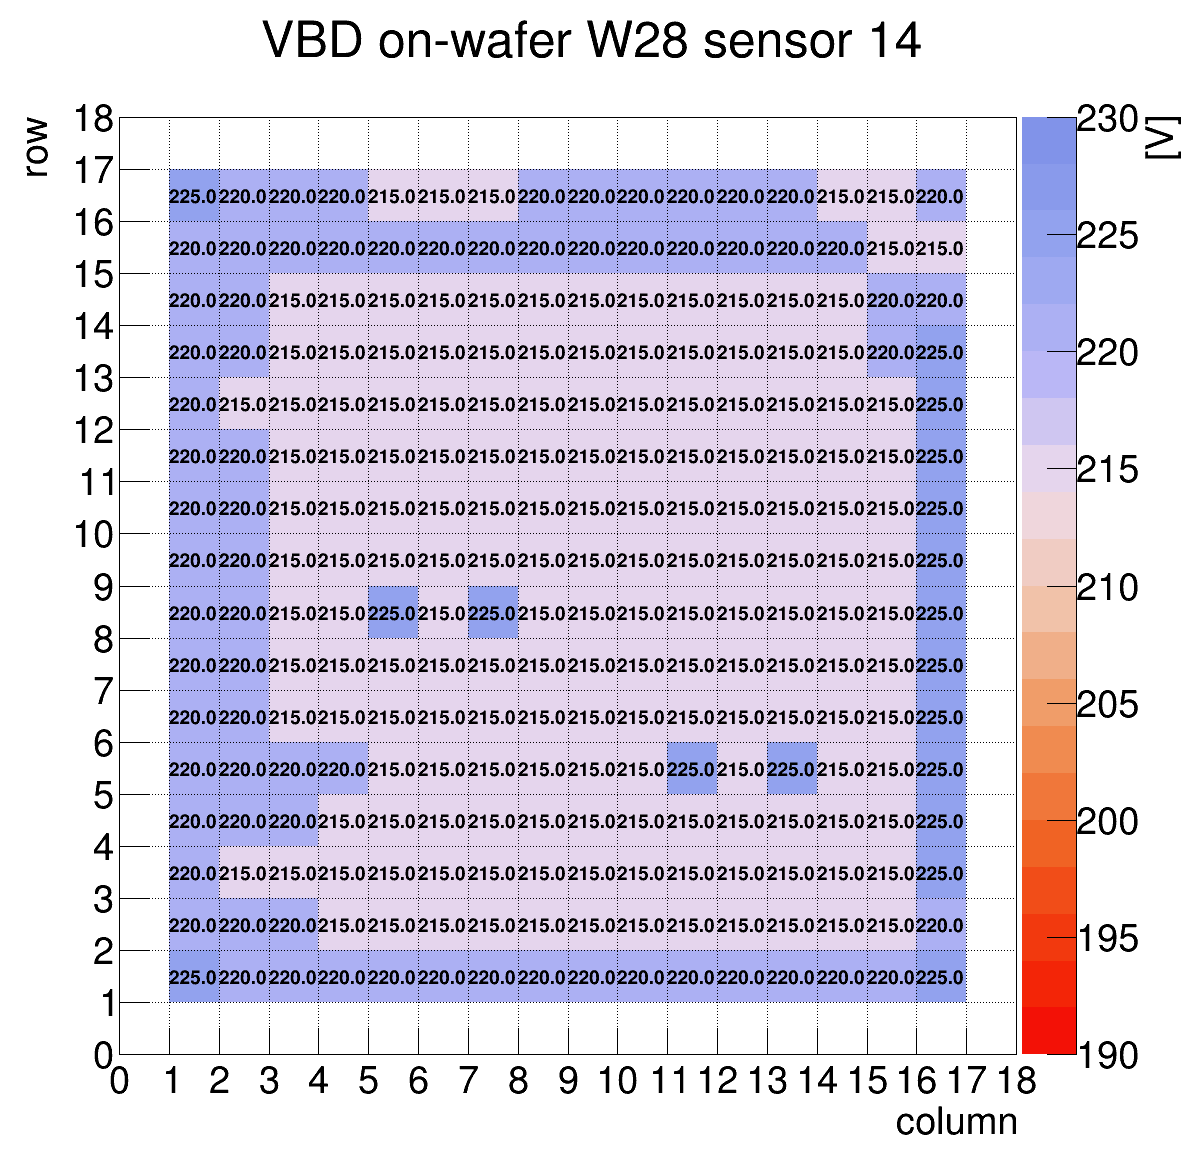

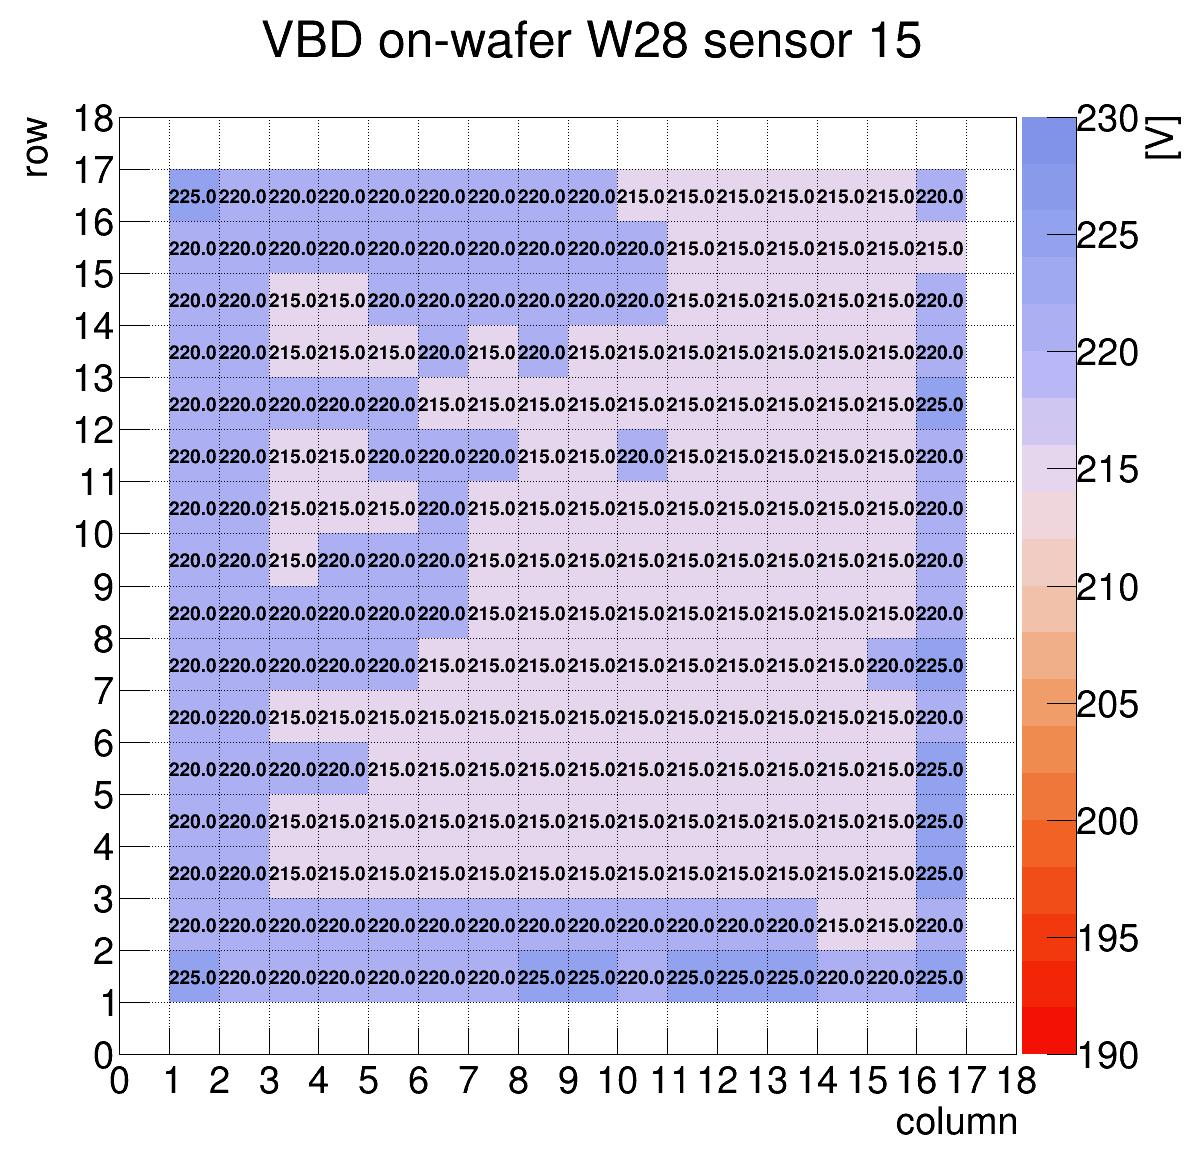

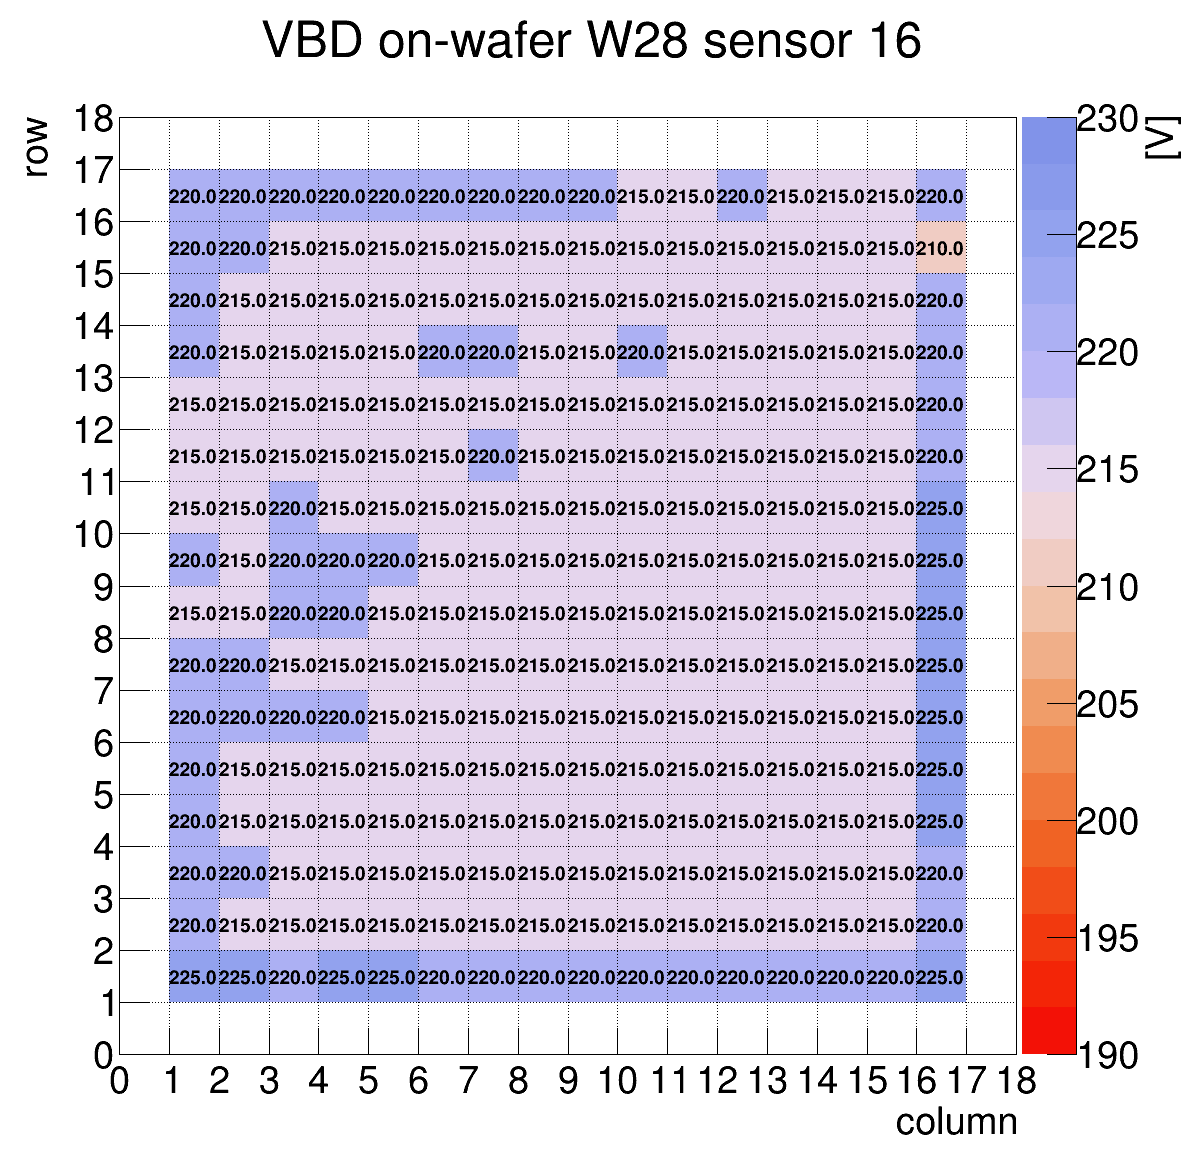

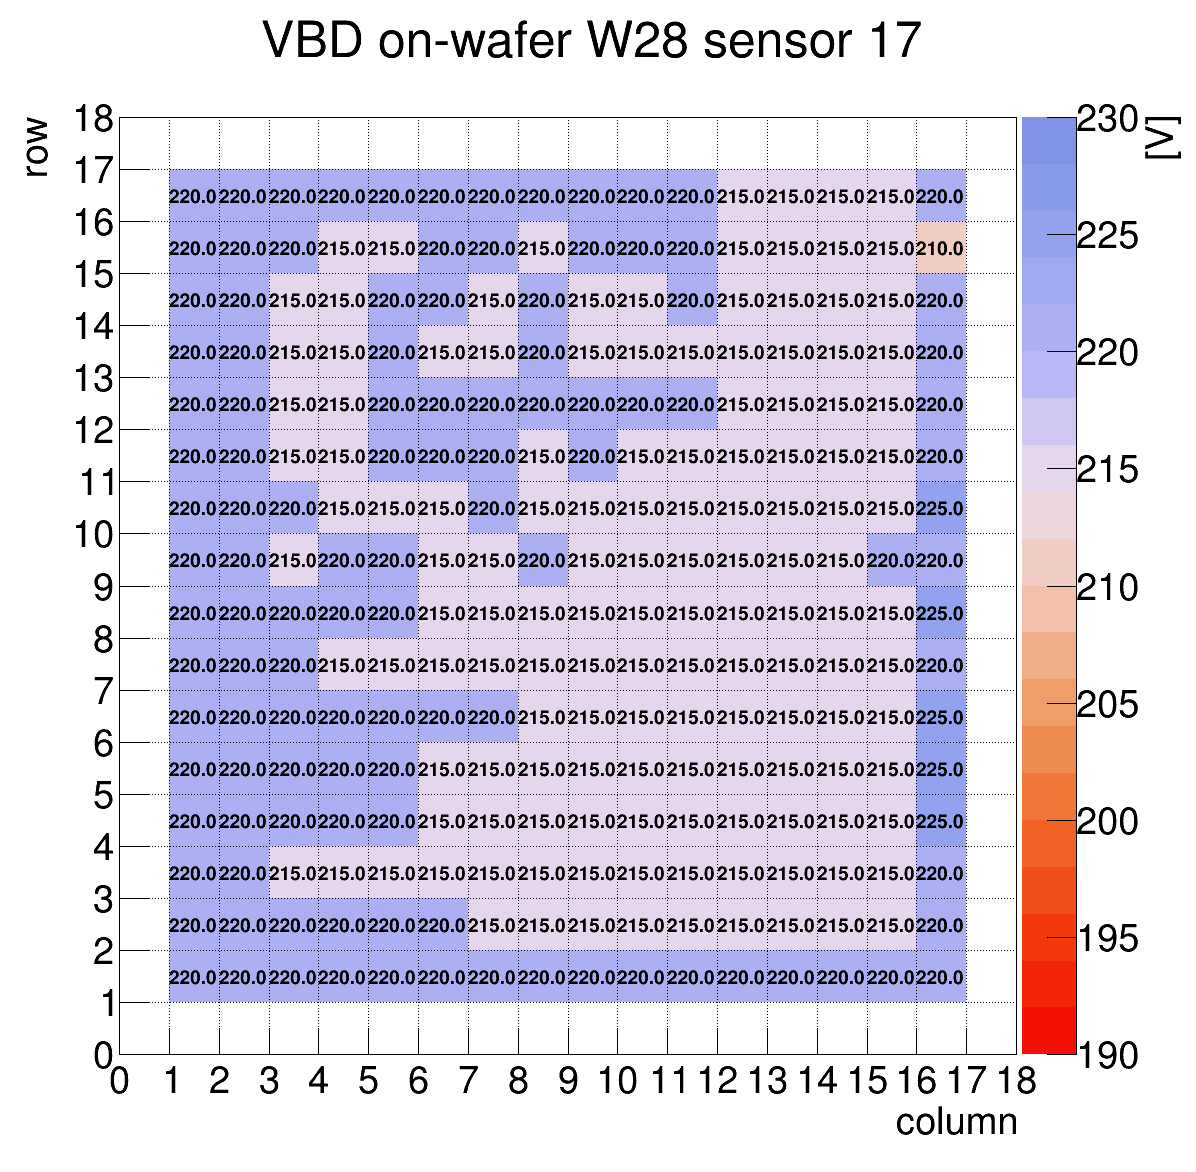

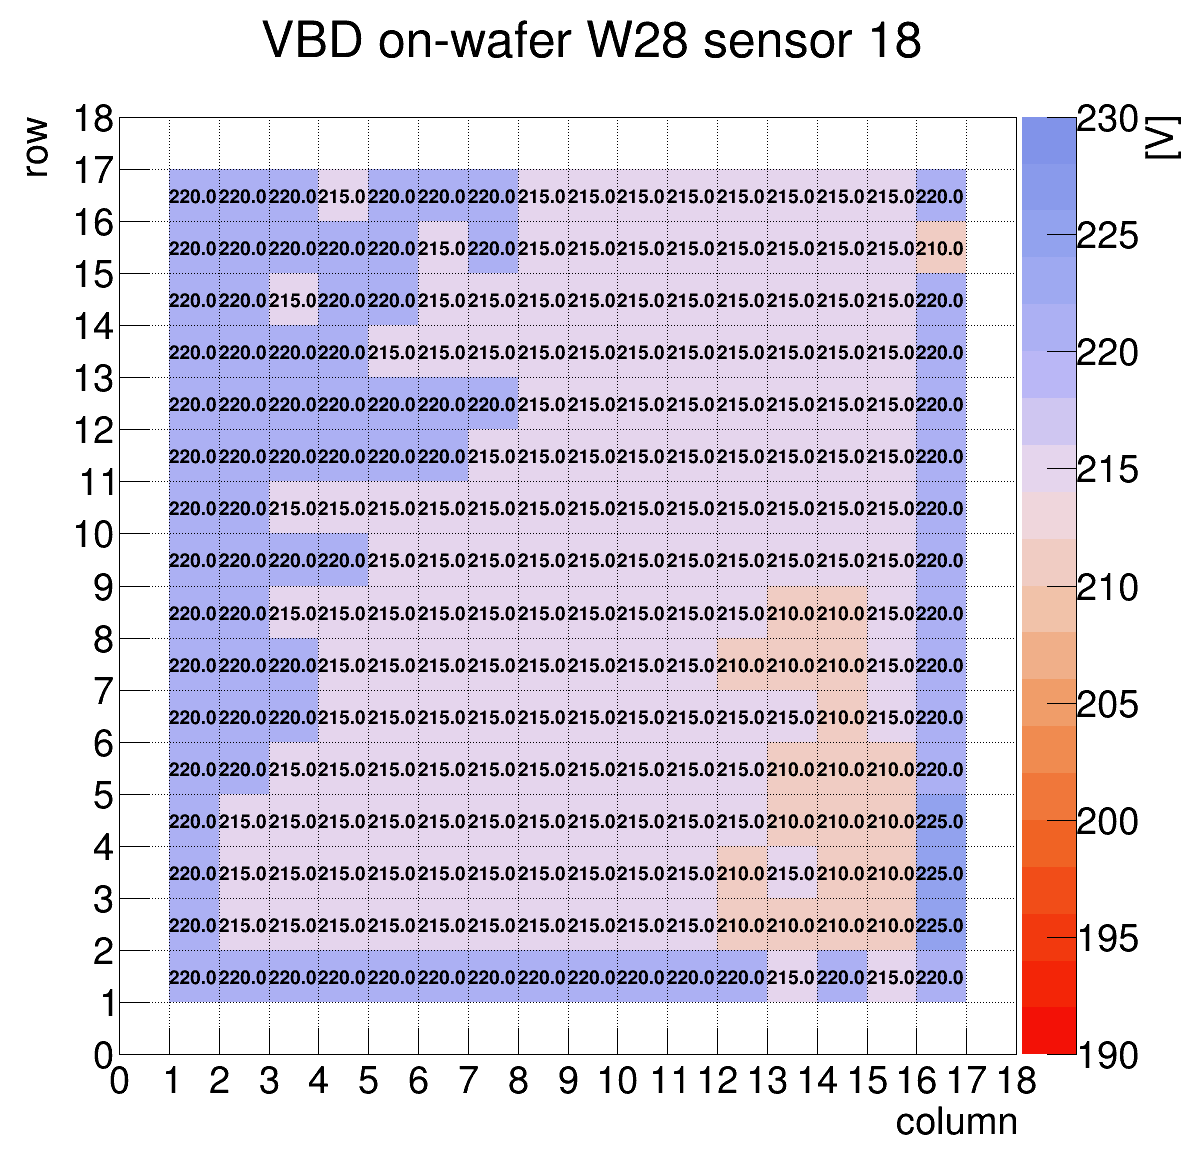

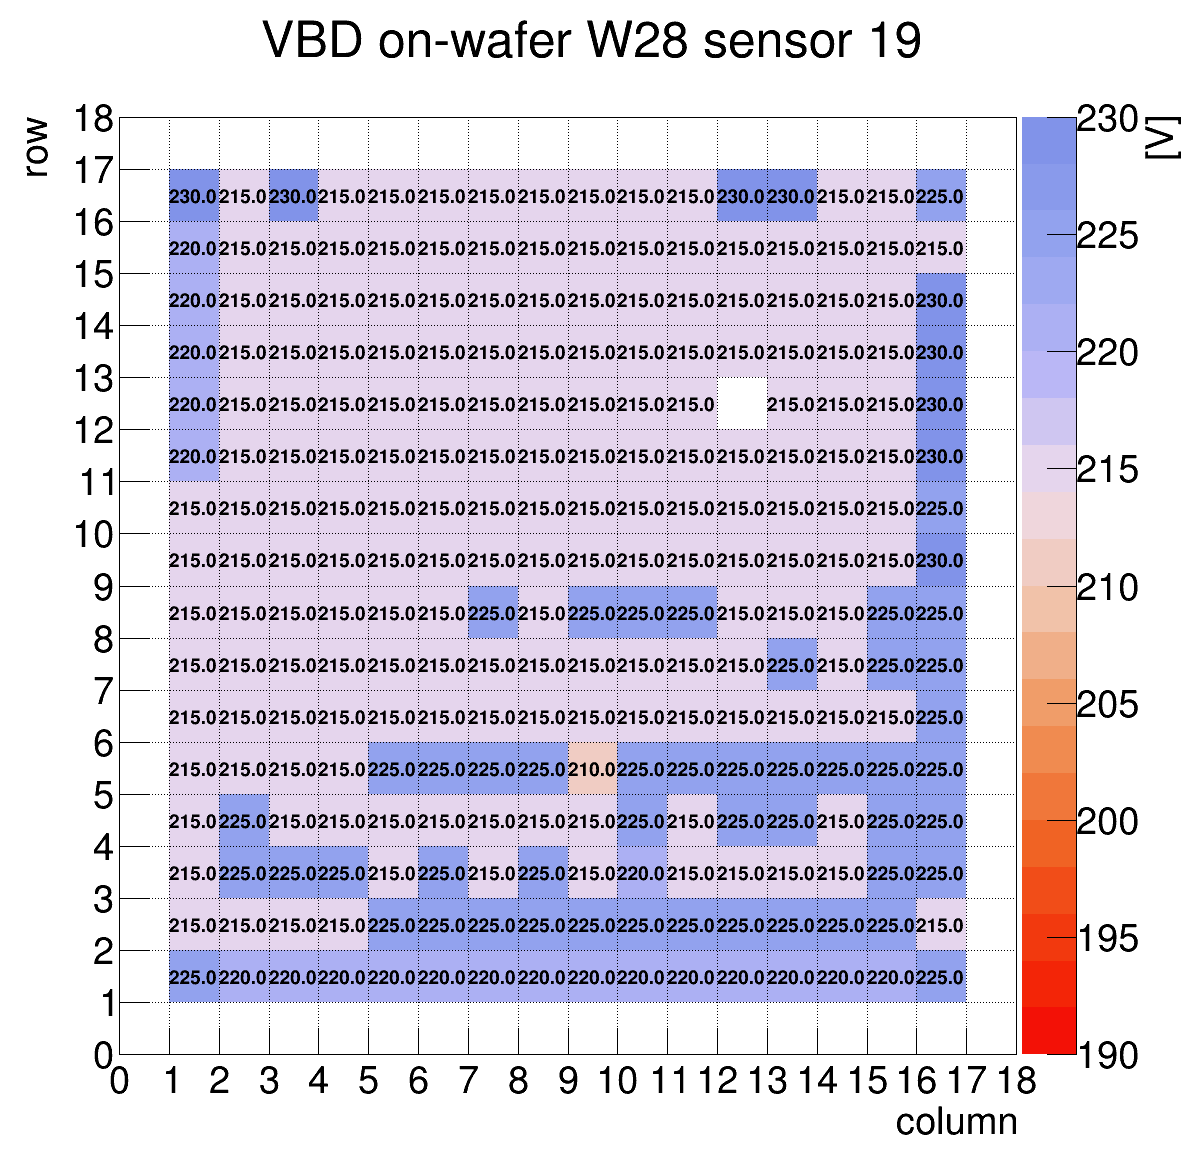

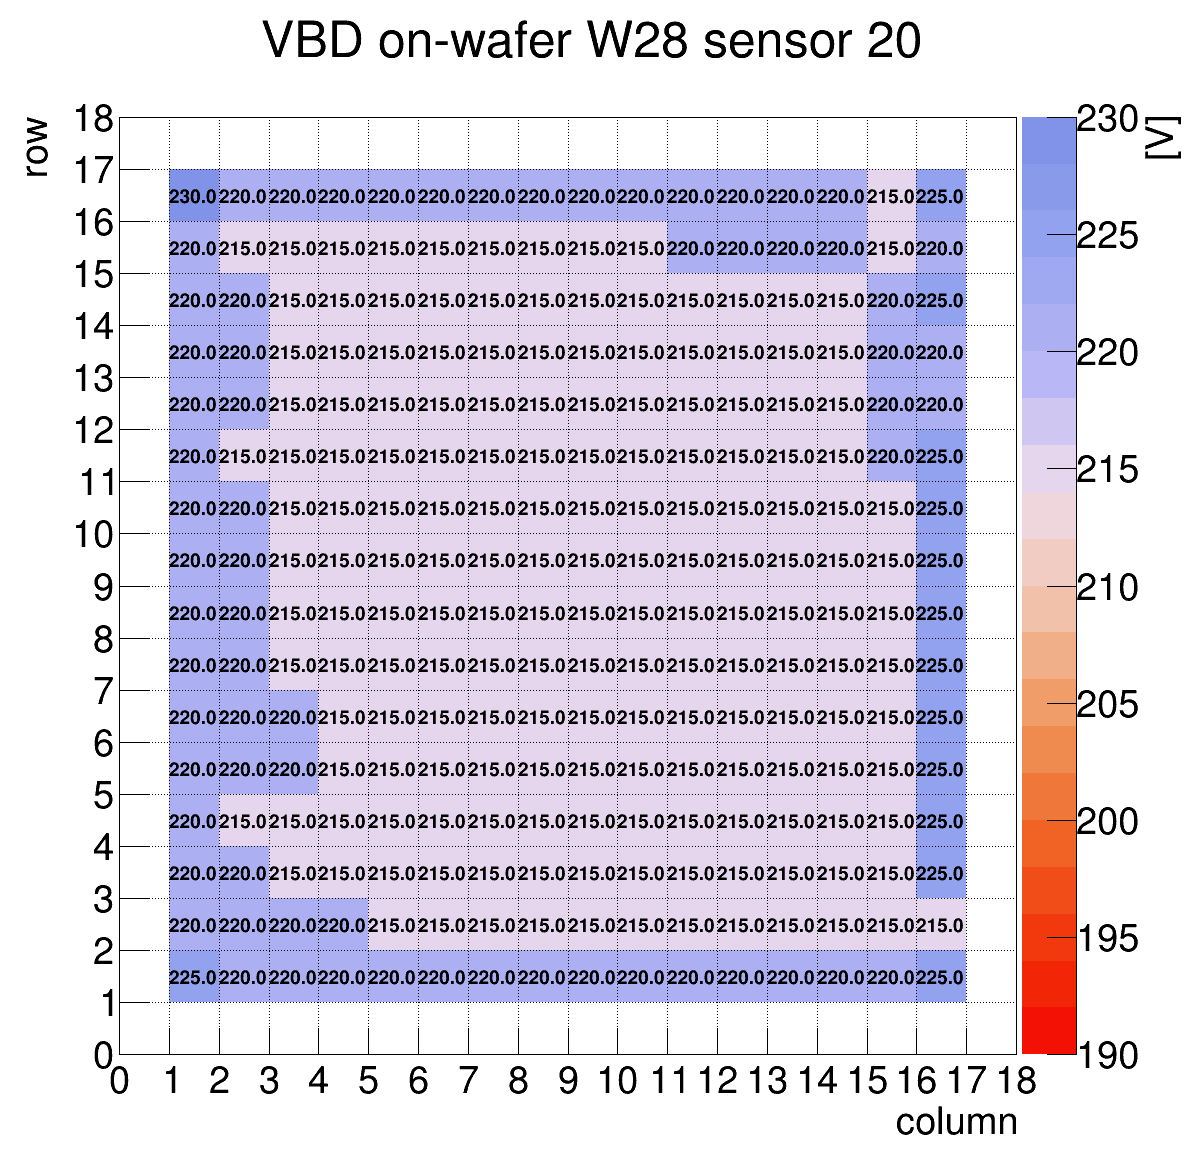

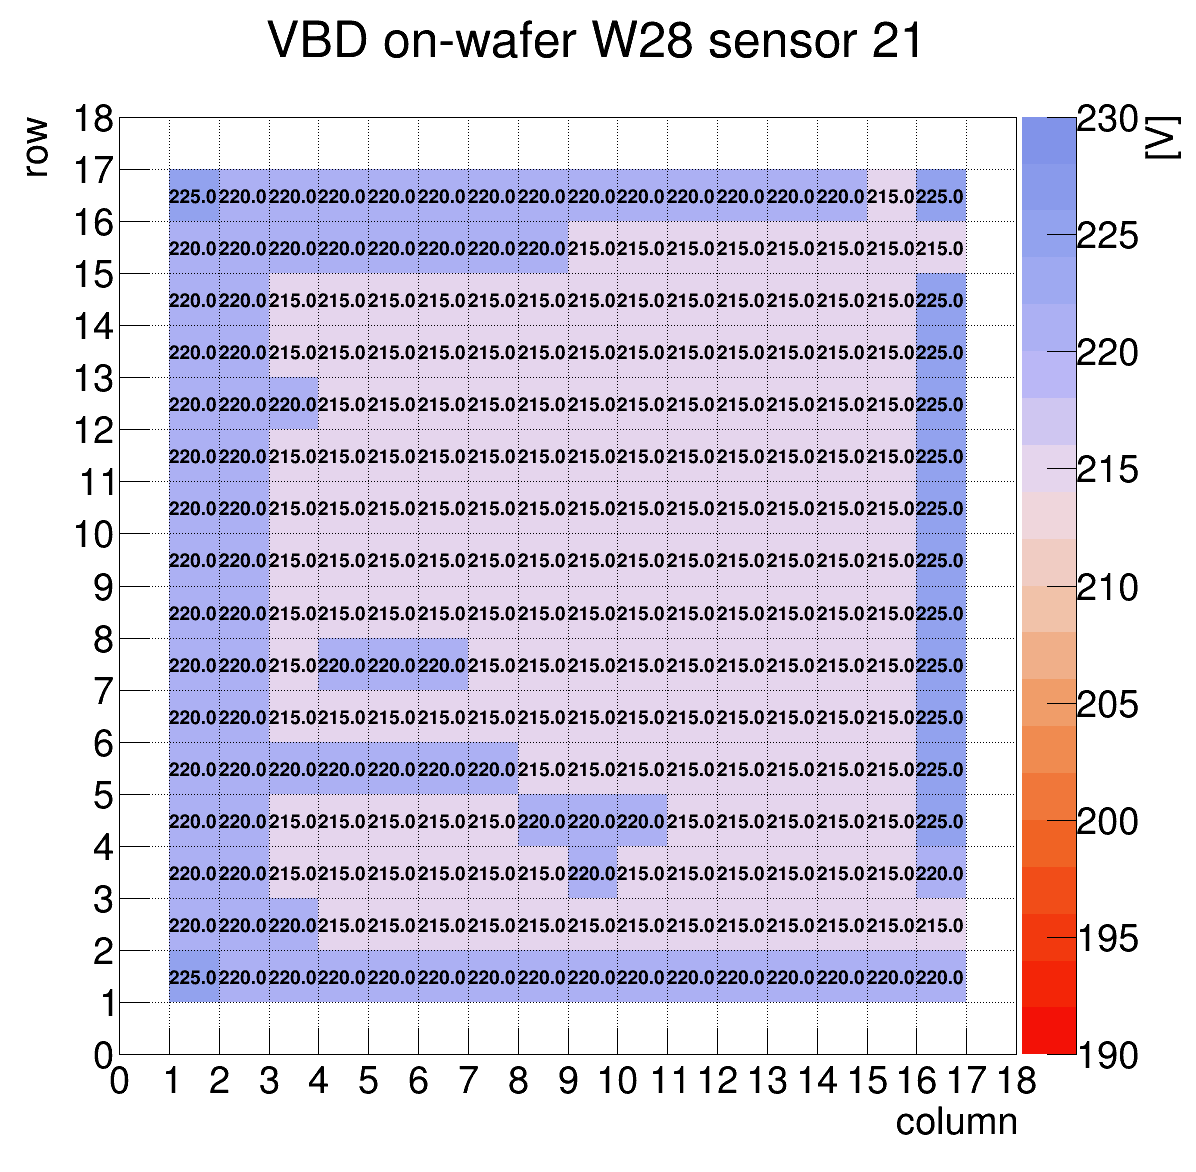

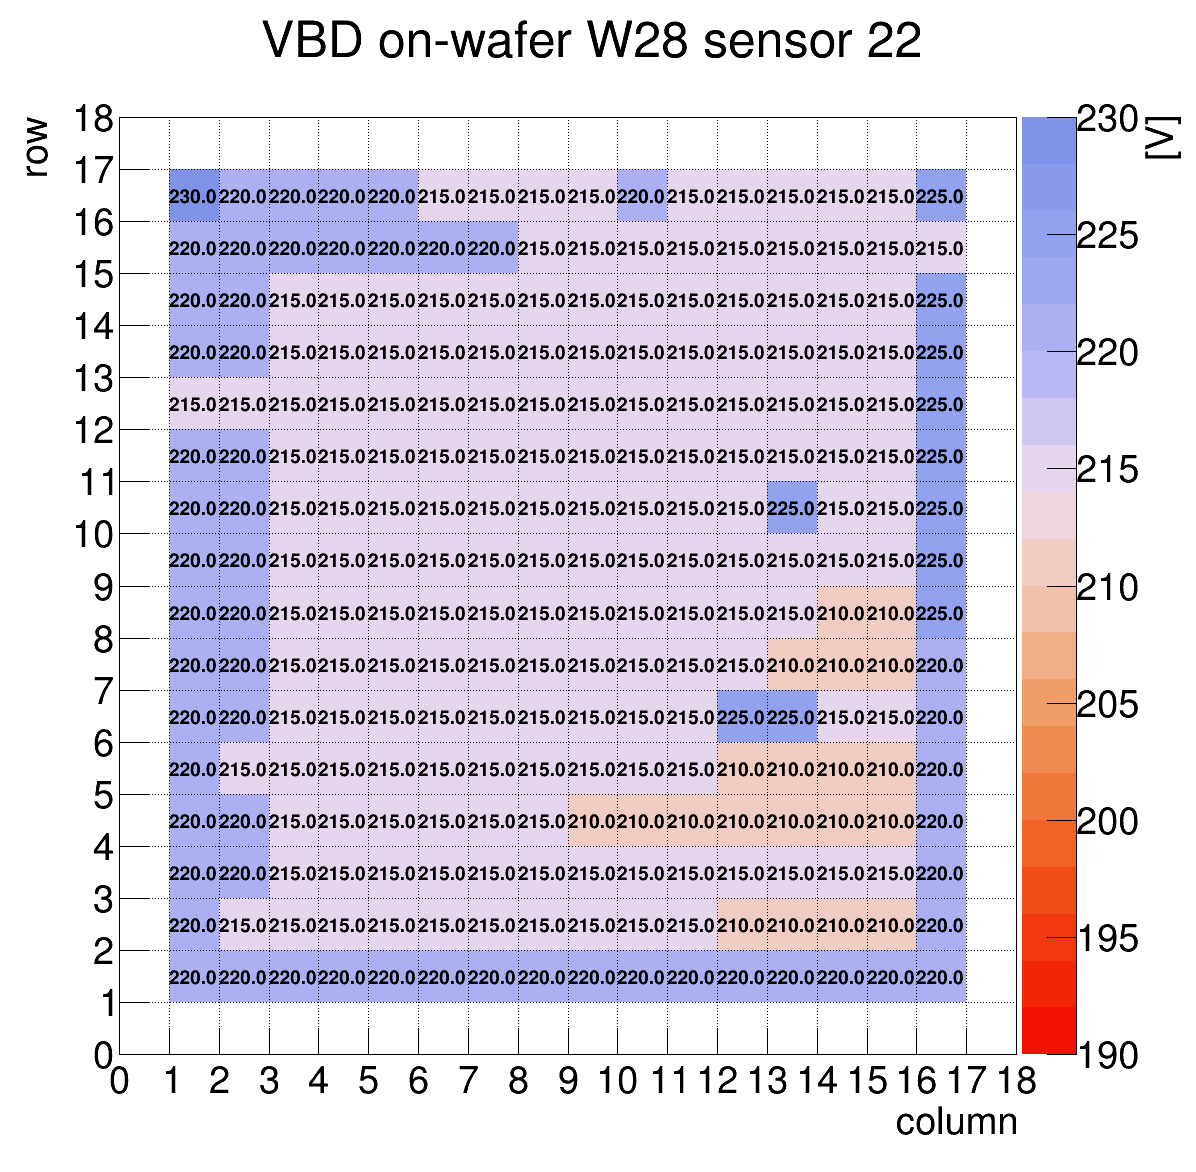

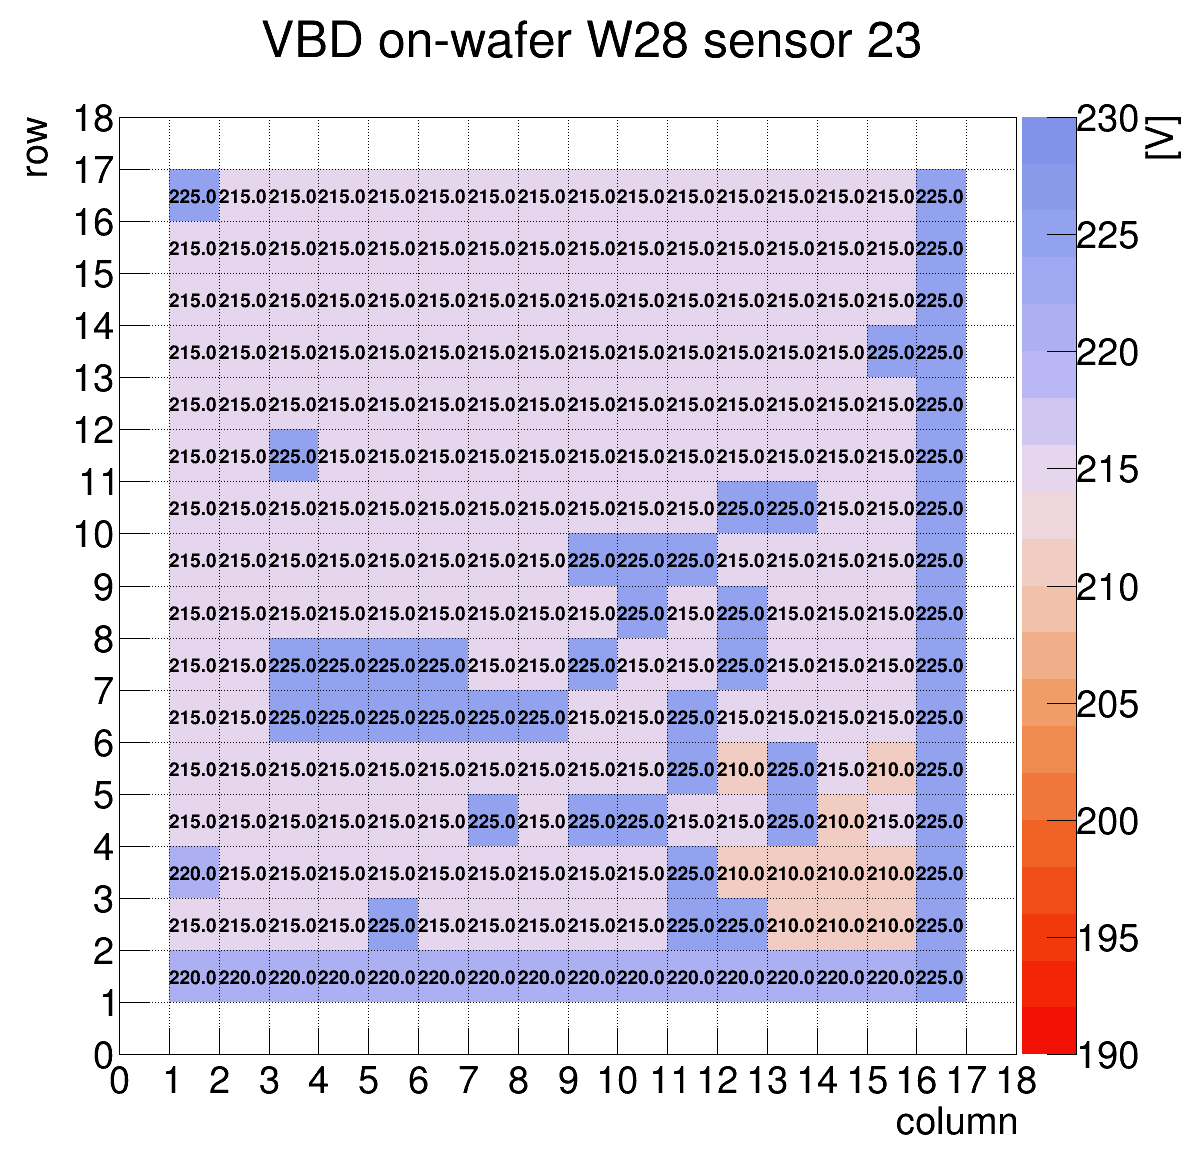

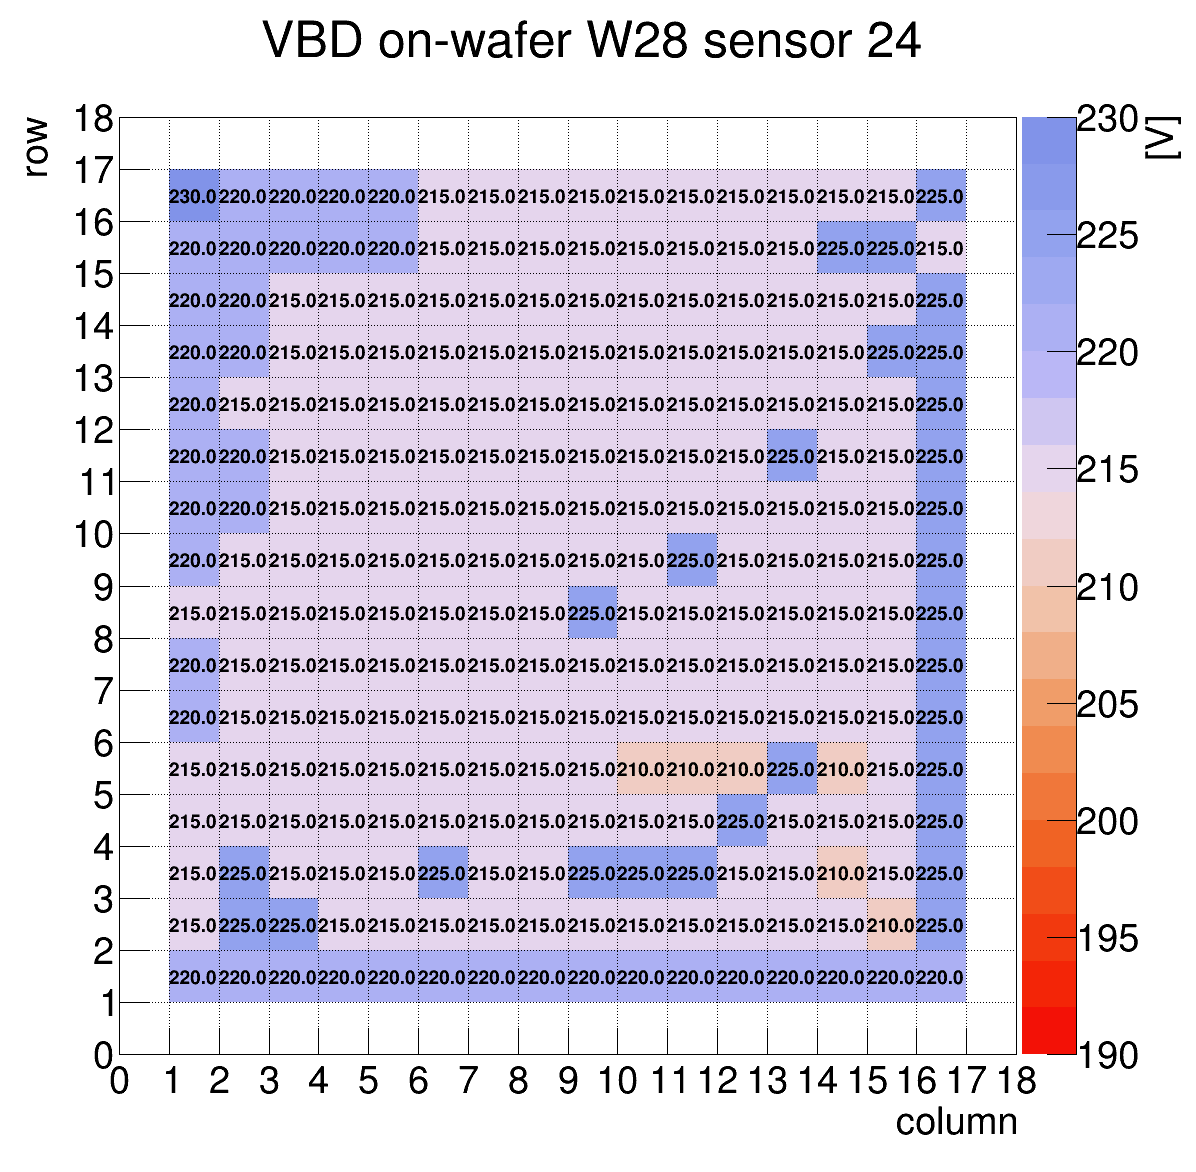

In [4]:
import cv2
import os

wafer = [3,4,6,7,8,9,10,11,12,28]

for wafer_n in wafer:

 hI_qa_100V = []
 hV_qa = []
 hbump_qa = []
 
 for i in range(n_sensor):
     hI_qa_100V.append( TH2F( "I_qa_"+str(210)+"V_W"+str(wafer_n)+"_sensor_"+str(i+1), "I@"+str(210)+"V on-wafer W"+str(wafer_n)+" sensor "+str(i+1), 18,0,18,18,0,18 ) )
     hV_qa.append( TH2F( "V_qa_W"+str(wafer_n)+"_sensor_"+str(i+1), "VBD on-wafer W"+str(wafer_n)+" sensor "+str(i+1), 18,0,18,18,0,18 ) )
     hbump_qa.append( TH2F( "Categories_qa_W"+str(wafer_n)+"_sensor_"+str(i+1), "Categories on-wafer W"+str(wafer_n)+" sensor "+str(i+1), 18,0,18,18,0,18 ) )
 
 for j in range(n_sensor):
         row_counter=0
         row_counter_bis=16
         for k in range(256):
              if k%16==0 and k!=0:
               row_counter += 1
               row_counter_bis -= 1
              #roww = k+start_pad-row_counter*16
              #coll = row_counter+start_pad
              coll = k+start_pad-row_counter*16
              #roww = row_counter_bis+start_pad
              roww = row_counter_bis
              
              if(vcount_vbd_qa[wafer_n-1][j][k]!=0): 
                #hV_qa[j].Fill( roww, coll, vvbd_qa[wafer_n-1][j][k]/vcount_vbd_qa[wafer_n-1][j][k] )
                hV_qa[j].Fill( coll, roww, vvbd_qa[wafer_n-1][j][k]/vcount_vbd_qa[wafer_n-1][j][k] )
                
              if(vcount_i_qa[wafer_n-1][j][k]!=0): 
                #print(vi_qa[wafer_n-1][j][k]/vcount_i_qa[wafer_n-1][j][k])
                #hI_qa_100V[j].Fill( roww, coll, vi_qa[wafer_n-1][j][k]/vcount_i_qa[wafer_n-1][j][k] )
                hI_qa_100V[j].Fill( coll, roww, vi_qa[wafer_n-1][j][k]/vcount_i_qa[wafer_n-1][j][k] )
              
              if( vcount_bump_qa[wafer_n-1][j][k] > 0 ):
               if( vbump_qa[wafer_n-1][j][k]/vcount_bump_qa[wafer_n-1][j][k]==1 ):
                  #hbump_qa[j].Fill(roww, coll, 1)
                  hbump_qa[j].Fill(coll, roww, 1)
               
               elif( vbump_qa[wafer_n-1][j][k]/vcount_bump_qa[wafer_n-1][j][k]>2 ):
                  #hbump_qa[j].Fill(roww, coll, 3)
                  hbump_qa[j].Fill(coll, roww, 3)
                      
               elif( vbump_qa[wafer_n-1][j][k]/vcount_bump_qa[wafer_n-1][j][k]>1 and vbump_qa[wafer_n-1][j][k]/vcount_bump_qa[wafer_n-1][j][k]<=2 ):
                 hbump_qa[j].Fill(coll, roww, 1) #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


 
 cI_100V = []
 cV = []
 cbump = []
 cnoisy = []
 
 for i in range(n_sensor):
   if(bcurrent):
     cI_100V.append(root.TCanvas("c_I_"+str(210)+"V_W"+str(i+1), "c I@"+str(210)+"V_W"+str(i+1), 1200,1200))
   if(bvoltage):
     cV.append(root.TCanvas("c_V_W"+str(wafer_n)+"_sensor_"+str(i+1), "c VBD_W"+str(wafer_n)+"_sensor_"+str(i+1), 1200,1200))
   if(bcategory):
     cbump.append(root.TCanvas("c_bump_W"+str(wafer_n)+"_sensor_"+str(i+1), "c bump_W"+str(wafer_n)+"_sensor_"+str(i+1), 1200,1200))
   if(bnoisy):
     cnoisy.append(root.TCanvas("c_noisy_W"+str(wafer_n)+"_sensor_"+str(i+1), "c noisy_W"+str(wafer_n)+"_sensor_"+str(i+1), 1000,1000))
 
 
 for i in range(n_sensor):
 #for i in range(1):
     hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
     hI_qa_100V[i].GetZaxis().SetTitle("[nA]")
     hI_qa_100V[i].GetXaxis().SetTitle("column")
     hI_qa_100V[i].GetYaxis().SetTitle("row")
     hI_qa_100V[i].SetMarkerSize(3.)
     #hI_qa_100V[i].GetXaxis().SetGridWidthStyle(11)
     hI_qa_100V[i].SetLineWidth(3)

     hV_qa[i].GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
     hV_qa[i].GetZaxis().SetTitle("[V]")
     hV_qa[i].GetXaxis().SetTitle("column") 
     hV_qa[i].GetYaxis().SetTitle("row")
     hV_qa[i].SetMarkerSize(3.)
 
     
     hbump_qa[i].GetZaxis().SetRangeUser( 1, 3 )
     hbump_qa[i].GetZaxis().SetTitle("Category")
     hbump_qa[i].GetXaxis().SetTitle("column")
     hbump_qa[i].GetYaxis().SetTitle("row")
     
     '''
     hnoisy_qa[i].GetZaxis().SetRangeUser( -0.1, 1 )
     hnoisy_qa[i].GetZaxis().SetTitle("Presence of bad pad(s)")
     hnoisy_qa[i].GetXaxis().SetTitle("column")
     hnoisy_qa[i].GetYaxis().SetTitle("row")
     '''
 
     if(bcurrent):
       #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
       cI_100V[i].SetRightMargin(0.15)
       cI_100V[i].cd()
       hI_qa_100V[i].SetMarkerSize(0.9)
       hI_qa_100V[i].Draw("textcolz")
       root.gPad.SetGrid(1,1)
       root.gPad.SetLogz(1)
       root.gPad.Update()
       cI_100V[i].Update()
       hI_qa_100V[i].GetXaxis().SetNdivisions(18)
       hI_qa_100V[i].GetYaxis().SetNdivisions(18)
   
       if(save):
         #cI_100V[i].SaveAs("pics/I_"+str(V_current_level)+"V_W"+str(i+1)+"_FINAL_py.png")
         #cI_100V[i].SaveAs(save_path+"I_"+str(V_current_level[i])+"V_s"+str(i+1)+".png")
         cI_100V[i].SaveAs(save_path+str(i+1)+".png")
 
 
     if(bvoltage):
       root.gStyle.SetPaintTextFormat("1.1f")
       #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
       cV[i].SetRightMargin(0.15)
       cV[i].cd()
       hV_qa[i].SetMarkerSize(0.9)
       hV_qa[i].Draw("textcolz")
       #hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
       root.gPad.SetGrid(1,1)
       root.gPad.Update()
       cV[i].Update()
       hV_qa[i].GetXaxis().SetNdivisions(18)
       hV_qa[i].GetYaxis().SetNdivisions(18)
   
       if(save): 
         #cV[i].SaveAs( "pics/VBD_W"+str(i+1)+"_FINAL_py.png",i+1)
         #cV[i].SaveAs(save_path+"VBD_s"+str(i+1)+".png")
         cV[i].SaveAs(save_path+str(i+1)+".png")
 
    
     if(bcategory):
       #cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
       cbump[i].SetRightMargin(0.15)
       cbump[i].cd()
       hbump_qa[i].Draw("colz")
       root.gPad.SetGrid(1,1)
       root.gPad.Update()
       cbump[i].Update()
       hbump_qa[i].GetXaxis().SetNdivisions(18)
       hbump_qa[i].GetYaxis().SetNdivisions(18)
        
       if(save):
         #cbump[i].SaveAs("pics/categories_W"+str(i+1)+"_FINAL_py.png" )
         #cbump[i].SaveAs(save_path+"categories_W"+str(i+1)+".png" )   
         cbump[i].SaveAs(save_path+str(i+1)+".png")
 
 
 
 
 # Define crop parameters
 x_offset = 165
 y_offset = 165
 width = 805
 height = 840
 
 image_dir = "/Users/icosivi/Desktop/plot_HPK5"  # Replace with the directory containing your images
 
 for filename in os.listdir(image_dir):
     if filename.endswith((".jpg", ".jpeg", ".png")):  # Adjust for your image file types
         img_path = os.path.join(image_dir, filename)
         img = cv2.imread(img_path)
         cropped_img = img[y_offset:y_offset+height, x_offset:x_offset+width] 
         #cv2.imwrite(os.path.join(image_dir, "cropped_" + filename), cropped_img)
         cv2.imwrite(os.path.join(image_dir, filename), cropped_img)
         
         
 
 def arrange_images_specific_pattern(images, rows, cols):
   """
   Arranges multiple images in a specific 6x6 matrix pattern with 24 images.
 
   Args:
     images: A list of image paths.
     rows: Number of rows in the grid (fixed to 6).
     cols: Number of columns in the grid (fixed to 6).
 
   Returns:
     A single image containing all input images arranged in the specified pattern.
   """
 
   if len(images) != 24:
     raise ValueError("This specific pattern requires exactly 24 images.")
 
   # Load images
   img_list = [cv2.imread(img_path) for img_path in images]
 
   # Get dimensions of each image
   heights, widths = zip(*(i.shape[:2] for i in img_list))
   max_height = max(heights)
   max_width = max(widths)
 
   # Create a blank canvas for the final image
   final_image = 255 * np.ones((rows * max_height, cols * max_width, 3), dtype=np.uint8)
 
   # Define the placement pattern (updated for 24 images)
   placement_map = [
       [0, 0, 1, 1, 0, 0],  # Row 1
       [0, 1, 1, 1, 1, 0],  # Row 2
       [1, 1, 1, 1, 1, 1],  # Row 3
       [1, 1, 1, 1, 1, 1],  # Row 4
       [0, 1, 1, 1, 1, 0],  # Row 5
       [0, 0, 1, 1, 0, 0]   # Row 6
   ]
 
   # Place images according to the pattern
   img_idx = 0
   for row in range(rows):
     for col in range(cols):
       if placement_map[row][col] == 1:
         img = img_list[img_idx]
         x_offset = col * max_width
         y_offset = row * max_height
         final_image[y_offset:y_offset+img.shape[0], x_offset:x_offset+img.shape[1]] = img
         img_idx += 1
 
   return final_image
 
 image_paths = []
 for filename in os.listdir("/Users/icosivi/Desktop/plot_HPK5"):
     print(filename)
     if filename.lower().endswith('.png'):
       image_paths.append(os.path.join("/Users/icosivi/Desktop/plot_HPK5", filename))
 
 rows = 6
 cols = 6
 
 image_paths = sorted(image_paths, key=lambda x: int((x.split('/')[5]).split('.')[0]))
 combined_image = arrange_images_specific_pattern(image_paths, rows, cols)
 
 # Save the combined image
 #cv2.imwrite("/Users/icosivi/Desktop/plot_HPK5/combined_cat_1000nA/combined_image_pattern_Wafer_"+str(wafer_n)+"_4nA.png", combined_image)
 #cv2.imwrite("/Users/icosivi/Desktop/plot_HPK5/combined_cat_1000nA/combined_image_pattern_Wafer_"+str(wafer_n)+"_4nA.png", combined_image)
 
 
 for filename in os.listdir("/Users/icosivi/Desktop/plot_HPK5/"):
     if filename.lower().endswith(".png"):
      file_path = os.path.join("/Users/icosivi/Desktop/plot_HPK5/", filename)
      os.remove(file_path)

In [ ]:
wafer_n = 11

hI_qa_100V = []
hV_qa = []
hbump_qa = []

for i in range(n_sensor):
    hI_qa_100V.append( TH2F( "I_qa_"+str(210)+"V_W"+str(wafer_n)+"_sensor_"+str(i+1), "I@"+str(210)+"V on-wafer W"+str(wafer_n)+" sensor "+str(i+1), 18,0,18,18,0,18 ) )
    hV_qa.append( TH2F( "V_qa_W"+str(wafer_n)+"_sensor_"+str(i+1), "VBD on-wafer W"+str(wafer_n)+" sensor "+str(i+1), 18,0,18,18,0,18 ) )
    hbump_qa.append( TH2F( "Categories_qa_W"+str(wafer_n)+"_sensor_"+str(i+1), "Categories on-wafer W"+str(wafer_n)+" sensor "+str(i+1), 18,0,18,18,0,18 ) )

for j in range(n_sensor):
        row_counter=0
        for k in range(256):
             if k%16==0 and k!=0:
              row_counter+=1
             roww = k+start_pad-row_counter*16
             coll = row_counter+start_pad
             
             if(vcount_vbd_qa[wafer_n-1][j][k]!=0): 
               hV_qa[j].Fill( roww, coll, vvbd_qa[wafer_n-1][j][k]/vcount_vbd_qa[wafer_n-1][j][k] )
               
             if(vcount_i_qa[wafer_n-1][j][k]!=0): 
               #print(vi_qa[wafer_n-1][j][k]/vcount_i_qa[wafer_n-1][j][k])
               hI_qa_100V[j].Fill( roww, coll, vi_qa[wafer_n-1][j][k]/vcount_i_qa[wafer_n-1][j][k] )
             
             if( vcount_bump_qa[wafer_n-1][j][k] > 0 ):
              if( vbump_qa[wafer_n-1][j][k]/vcount_bump_qa[wafer_n-1][j][k]==1 ):
                 hbump_qa[j].Fill(roww, coll, 1)
              
              elif( vbump_qa[wafer_n-1][j][k]/vcount_bump_qa[wafer_n-1][j][k]>2 ):
                 hbump_qa[j].Fill(roww, coll, 3)
                     
              elif( vbump_qa[wafer_n-1][j][k]/vcount_bump_qa[wafer_n-1][j][k]>1 and vbump_qa[wafer_n-1][j][k]/vcount_bump_qa[wafer_n-1][j][k]<=2 ):
                 hbump_qa[j].Fill(roww, coll, 2)

In [ ]:
cI_100V = []
cV = []
cbump = []
cnoisy = []

for i in range(n_sensor):
  if(bcurrent):
    cI_100V.append(root.TCanvas("c_I_"+str(210)+"V_W"+str(i+1), "c I@"+str(210)+"V_W"+str(i+1), 1200,1200))
  if(bvoltage):
    cV.append(root.TCanvas("c_V_W"+str(wafer_n)+"_sensor_"+str(i+1), "c VBD_W"+str(wafer_n)+"_sensor_"+str(i+1), 1200,1200))
  if(bcategory):
    cbump.append(root.TCanvas("c_bump_W"+str(wafer_n)+"_sensor_"+str(i+1), "c bump_W"+str(wafer_n)+"_sensor_"+str(i+1), 1200,1200))
  if(bnoisy):
    cnoisy.append(root.TCanvas("c_noisy_W"+str(wafer_n)+"_sensor_"+str(i+1), "c noisy_W"+str(wafer_n)+"_sensor_"+str(i+1), 1000,1000))


for i in range(n_sensor):
#for i in range(1):
    #hI_qa_100V[i]->GetZaxis()->SetRangeUser( 0.1, hI_qa_100V[i]->GetMaximum() ) #Alternative colored axis range
    hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
    hI_qa_100V[i].GetZaxis().SetTitle("[nA]")
    hI_qa_100V[i].GetXaxis().SetTitle("column")
    hI_qa_100V[i].GetYaxis().SetTitle("row")
    hI_qa_100V[i].SetMarkerSize(3.)
    #hI_qa_100V[i].GetXaxis().SetGridWidthStyle(11)
    hI_qa_100V[i].SetLineWidth(3)

  
    #hV_qa[i]->GetZaxis()->SetRangeUser( hV_qa[i]->GetMinimum(), hV_qa[i]->GetMaximum() ); //Alternative colored axis range
    hV_qa[i].GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
    hV_qa[i].GetZaxis().SetTitle("[V]")
    hV_qa[i].GetXaxis().SetTitle("column") 
    hV_qa[i].GetYaxis().SetTitle("row")
    hV_qa[i].SetMarkerSize(3.)

    
    hbump_qa[i].GetZaxis().SetRangeUser( 1, 3 )
    hbump_qa[i].GetZaxis().SetTitle("Category")
    hbump_qa[i].GetXaxis().SetTitle("column")
    hbump_qa[i].GetYaxis().SetTitle("row")
    
    '''
    hnoisy_qa[i].GetZaxis().SetRangeUser( -0.1, 1 )
    hnoisy_qa[i].GetZaxis().SetTitle("Presence of bad pad(s)")
    hnoisy_qa[i].GetXaxis().SetTitle("column")
    hnoisy_qa[i].GetYaxis().SetTitle("row")
    '''

    if(bcurrent):
      #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
      cI_100V[i].SetRightMargin(0.15)
      cI_100V[i].cd()
      hI_qa_100V[i].SetMarkerSize(0.9)
      hI_qa_100V[i].Draw("textcolz")
      root.gPad.SetGrid(1,1)
      root.gPad.SetLogz(1)
      root.gPad.Update()
      cI_100V[i].Update()
      hI_qa_100V[i].GetXaxis().SetNdivisions(18)
      hI_qa_100V[i].GetYaxis().SetNdivisions(18)
  
      if(save):
        #cI_100V[i].SaveAs("pics/I_"+str(V_current_level)+"V_W"+str(i+1)+"_FINAL_py.png")
        #cI_100V[i].SaveAs(save_path+"I_"+str(V_current_level[i])+"V_s"+str(i+1)+".png")
        cI_100V[i].SaveAs(save_path+str(i+1)+".png")


    if(bvoltage):
      root.gStyle.SetPaintTextFormat("1.1f")
      #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
      cV[i].SetRightMargin(0.15)
      cV[i].cd()
      hV_qa[i].SetMarkerSize(0.9)
      hV_qa[i].Draw("textcolz")
      #hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cV[i].Update()
      hV_qa[i].GetXaxis().SetNdivisions(18)
      hV_qa[i].GetYaxis().SetNdivisions(18)
  
      if(save): 
        #cV[i].SaveAs( "pics/VBD_W"+str(i+1)+"_FINAL_py.png",i+1)
        #cV[i].SaveAs(save_path+"VBD_s"+str(i+1)+".png")
        cV[i].SaveAs(save_path+str(i+1)+".png")

   
    if(bcategory):
      #cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
      cbump[i].SetRightMargin(0.15)
      cbump[i].cd()
      hbump_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cbump[i].Update()
      hbump_qa[i].GetXaxis().SetNdivisions(18)
      hbump_qa[i].GetYaxis().SetNdivisions(18)
       
      if(save):
        #cbump[i].SaveAs("pics/categories_W"+str(i+1)+"_FINAL_py.png" )
        #cbump[i].SaveAs(save_path+"categories_W"+str(i+1)+".png" )   
        cbump[i].SaveAs(save_path+str(i+1)+".png")

    '''
    if(bnoisy):
      #cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))
      cnoisy[i].SetRightMargin(0.15)
      cnoisy[i].cd()
      hnoisy_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cnoisy[i].Update()
      hnoisy_qa[i].GetXaxis().SetNdivisions(n_sensor)
      hnoisy_qa[i].GetYaxis().SetNdivisions(n_pad)
       
      if(save):
        cnoisy[i].SaveAs("pics/noisy_W"+str(i+1)+".png")
    '''

In [ ]:
import cv2
import os

# Define crop parameters
x_offset = 165
y_offset = 165
width = 805
height = 840

image_dir = "/Users/icosivi/Desktop/plot_HPK5"  # Replace with the directory containing your images

for filename in os.listdir(image_dir):
    if filename.endswith((".jpg", ".jpeg", ".png")):  # Adjust for your image file types
        img_path = os.path.join(image_dir, filename)
        img = cv2.imread(img_path)
        cropped_img = img[y_offset:y_offset+height, x_offset:x_offset+width] 
        #cv2.imwrite(os.path.join(image_dir, "cropped_" + filename), cropped_img)
        cv2.imwrite(os.path.join(image_dir, filename), cropped_img)

In [ ]:
import cv2
import numpy as np

def arrange_images_specific_pattern(images, rows, cols):
  """
  Arranges multiple images in a specific 6x6 matrix pattern with 24 images.

  Args:
    images: A list of image paths.
    rows: Number of rows in the grid (fixed to 6).
    cols: Number of columns in the grid (fixed to 6).

  Returns:
    A single image containing all input images arranged in the specified pattern.
  """

  if len(images) != 24:
    raise ValueError("This specific pattern requires exactly 24 images.")

  # Load images
  img_list = [cv2.imread(img_path) for img_path in images]

  # Get dimensions of each image
  heights, widths = zip(*(i.shape[:2] for i in img_list))
  max_height = max(heights)
  max_width = max(widths)

  # Create a blank canvas for the final image
  final_image = 255 * np.ones((rows * max_height, cols * max_width, 3), dtype=np.uint8)

  # Define the placement pattern (updated for 24 images)
  placement_map = [
      [0, 0, 1, 1, 0, 0],  # Row 1
      [0, 1, 1, 1, 1, 0],  # Row 2
      [1, 1, 1, 1, 1, 1],  # Row 3
      [1, 1, 1, 1, 1, 1],  # Row 4
      [0, 1, 1, 1, 1, 0],  # Row 5
      [0, 0, 1, 1, 0, 0]   # Row 6
  ]

  # Place images according to the pattern
  img_idx = 0
  for row in range(rows):
    for col in range(cols):
      if placement_map[row][col] == 1:
        img = img_list[img_idx]
        x_offset = col * max_width
        y_offset = row * max_height
        final_image[y_offset:y_offset+img.shape[0], x_offset:x_offset+img.shape[1]] = img
        img_idx += 1

  return final_image

image_paths = []
for filename in os.listdir("/Users/icosivi/Desktop/plot_HPK5"):
    print(filename)
    if filename.lower().endswith('.png'):
      image_paths.append(os.path.join("/Users/icosivi/Desktop/plot_HPK5", filename))

rows = 6
cols = 6

image_paths = sorted(image_paths, key=lambda x: int((x.split('/')[5]).split('.')[0]))
combined_image = arrange_images_specific_pattern(image_paths, rows, cols)

# Save the combined image
cv2.imwrite("/Users/icosivi/Desktop/plot_HPK5/combined_cat/combined_image_pattern_Wafer_"+str(wafer_n)+"_4nA.png", combined_image)

In [ ]:
for filename in os.listdir("/Users/icosivi/Desktop/plot_HPK5/"):
    if filename.lower().endswith(".png"):
     file_path = os.path.join("/Users/icosivi/Desktop/plot_HPK5/", filename)
     os.remove(file_path)